In [19]:
import tidy3d as td
import numpy as np
import tidy3d.web as web
import matplotlib.pyplot as plt

import math
import os
from pathlib import Path

# import need be changed in some cases

# --- 1. Material Definitions ---
# Using fixed indices for 1550nm for simplicity

wdth_points = 100                               # number of width wv_points
num_modes = 2                                   # max number of modes to look up
core_thickness = 0.4

sweep_wavelength = np.linspace(1.550,1.5522,6) # Sweep on wavelengths
sweep_freq = td.C_0 / sweep_wavelength          # Sweep on Frequencies
sweep_width = np.linspace(0.6,1.5,wdth_points) #sweep on widths


web.configure("U7IS5Q1AW3qYVxPAAQDE7vgxaTz6Kt6aI9AioPZUajVRQQ2o")


Configuration saved successfully.


In [20]:
def n_SiN (wavelength):

    return np.sqrt(1+(2.9144*wavelength**2)/(wavelength**2-0.1366**2)+(0.004873)/(wavelength**2-1.6606**2))


def n_SiO2 (wavelength):

    return np.sqrt(1+(1.1056*wavelength**2)/(wavelength**2-0.078**2)+(2.360*wavelength**2)/(wavelength**2-16.681**2)) + 0.002



print(f"Silicon Nitride: {n_SiN(1.55)}")
print(f"Silica: {n_SiO2(1.55)}")

Silicon Nitride: 1.9807799816328062
Silica: 1.4469404291704726


In [21]:
version_name = "SiN_sim_400_plt_V2"

project_dir = Path.cwd()  # directory where notebook is located
data_dir = project_dir / "data_STRp_SiN_mode_analysis"
data_dir.mkdir(parents=True, exist_ok=True)


def build_mode_simulation(
    core_width = np.array([0.600]),
    core_thickness = 0.400,
    wavelength = np.array([1.550]),
    version_name = "SiN_Modal_analysis"
):

    base_path = f"data_STRp_SiN_mode_analysis/{version_name}"
    os.makedirs(base_path, exist_ok=True)

    # Materials
    core_n = n_SiN(wavelength)
    clad_n = n_SiO2(wavelength)

    # --- We define the simulation data array and simulation objects for the two different sweeps----

    sim_data_arr = [[],[]] # Simulation data for 220nm , TE and TM modes separated
    sim_arr = [[],[]]      # Simulation objects for 220nm and Width sweep, TE and TM modes separated
    estimate = 0

    for (pol_idx,pol_value) in enumerate(['TE','TM']):
        pol_folder = f"{base_path}/pol"+pol_value
        os.makedirs(pol_folder, exist_ok=True)

        for (width_idx,width_values) in enumerate(core_width):

            filename = f"{pol_folder}/width_{int(width_values*1000)}.hdf5"


            core_medium = td.Medium(
            name = 'core_SiN_medium',
            permittivity = 1.99**2,
            )

            cladd_medium = td.Medium(
            name = 'cladd_SiO2_medium',
            permittivity = 1.4469404291704726**2,
            )


            waveguide = td.Structure(
                geometry = td.Box(size = [td.inf, width_values, core_thickness]),
                name = 'waveguide',
                medium = core_medium
            )


            # --- Simulation domain ---
            sim_arr[pol_idx].append(td.ModeSimulation(
                freqs = sweep_freq,
                mode_spec = td.ModeSpec(target_neff = 1.99,num_modes=4, sort_spec = {'filter_reference' : 0, 'filter_order':'over', 'sort_order':'ascending', 'track_freq':'central'}, group_index_step = True, ),
                size = [7, 7, 7],
                grid_spec = td.GridSpec(grid_x = td.AutoGrid(min_steps_per_wvl = 11, ), grid_y = td.AutoGrid(min_steps_per_wvl = 11, ), grid_z = td.AutoGrid(min_steps_per_wvl = 11, ), wavelength = 1.550, ),
                version = '2.10.1',
                medium = cladd_medium,
                sources = [],
                monitors = [],
                structures = [waveguide],
                symmetry= [0,0,1] if pol_value == 'TE' else [0,0,-1],
                plane= td.Box(center=[0,0,0], size=[0,7,7])
            ))


            if os.path.exists(filename):
                # print(f"Loading {filename}")
                filename_path = Path(filename)
                sim_data_arr[pol_idx].append(td.ModeSimulationData.from_file(filename_path))

            else:
                task_name = f"{version_name}_P"+pol_value+f"_W{int(width_values*1000)}"
                job = web.Job(simulation= sim_arr[pol_idx][width_idx], task_name=task_name)

                # print(f"Running simulation: {task_name}")
                sim_data_arr[pol_idx].append(job.run())
                sim_data_arr[pol_idx][width_idx].to_file(filename)

                Job = web.Job(simulation= sim_arr[pol_idx][width_idx], task_name="my_sim")

                estimate += Job.estimate_cost()

        # sim_data_arr[pol_idx].append([])
        # sim_arr[pol_idx].append([])

    print(f"Estimated Maximum Cost: {estimate}")

    return sim_data_arr, sim_arr

sim_data_arr_modes,sim_data_modes = build_mode_simulation(wavelength=sweep_wavelength,core_width=sweep_width,core_thickness=core_thickness,version_name=version_name)

21:54:06 Hora est. Pacífico, Sudamérica WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

                                        WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

                                        WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

21:54:07 Hora est. Pacífico, Sudamérica WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

                                        WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

...

                                        WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

                                        WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

                                        WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

                                        WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

Estimated Maximum Cost: 0


In [22]:
neff,num_modes_count  = [  [[[],[]]],[[[],[]]]  ]    ,   [[[]],[[]]]

for (pol_idx,pol_value) in enumerate(['TE','TM']):
    for (wave_idx,wave_values) in enumerate(sweep_wavelength):
        for (width_idx,width_values) in enumerate(sweep_width):

            neff_values = sim_data_arr_modes[pol_idx][width_idx].modes_raw.n_complex.abs.isel(f = wave_idx).squeeze().values
            bool_array = neff_values > 1.4469404291704726

            for bool_idx,bool_val in enumerate(bool_array):
                if bool_val:
                    neff[pol_idx][wave_idx][bool_idx].append(sim_data_arr_modes[pol_idx][width_idx].modes_raw.n_complex.abs.isel(f = wave_idx, mode_index = bool_idx).squeeze().values)

            total_true = np.array(bool_array == True).sum().item()
            num_modes_count [pol_idx][wave_idx].append(total_true)
        neff[pol_idx].append([[],[]])
        num_modes_count [pol_idx].append([])

    neff[pol_idx].remove([[],[]])
    num_modes_count [pol_idx].remove([])

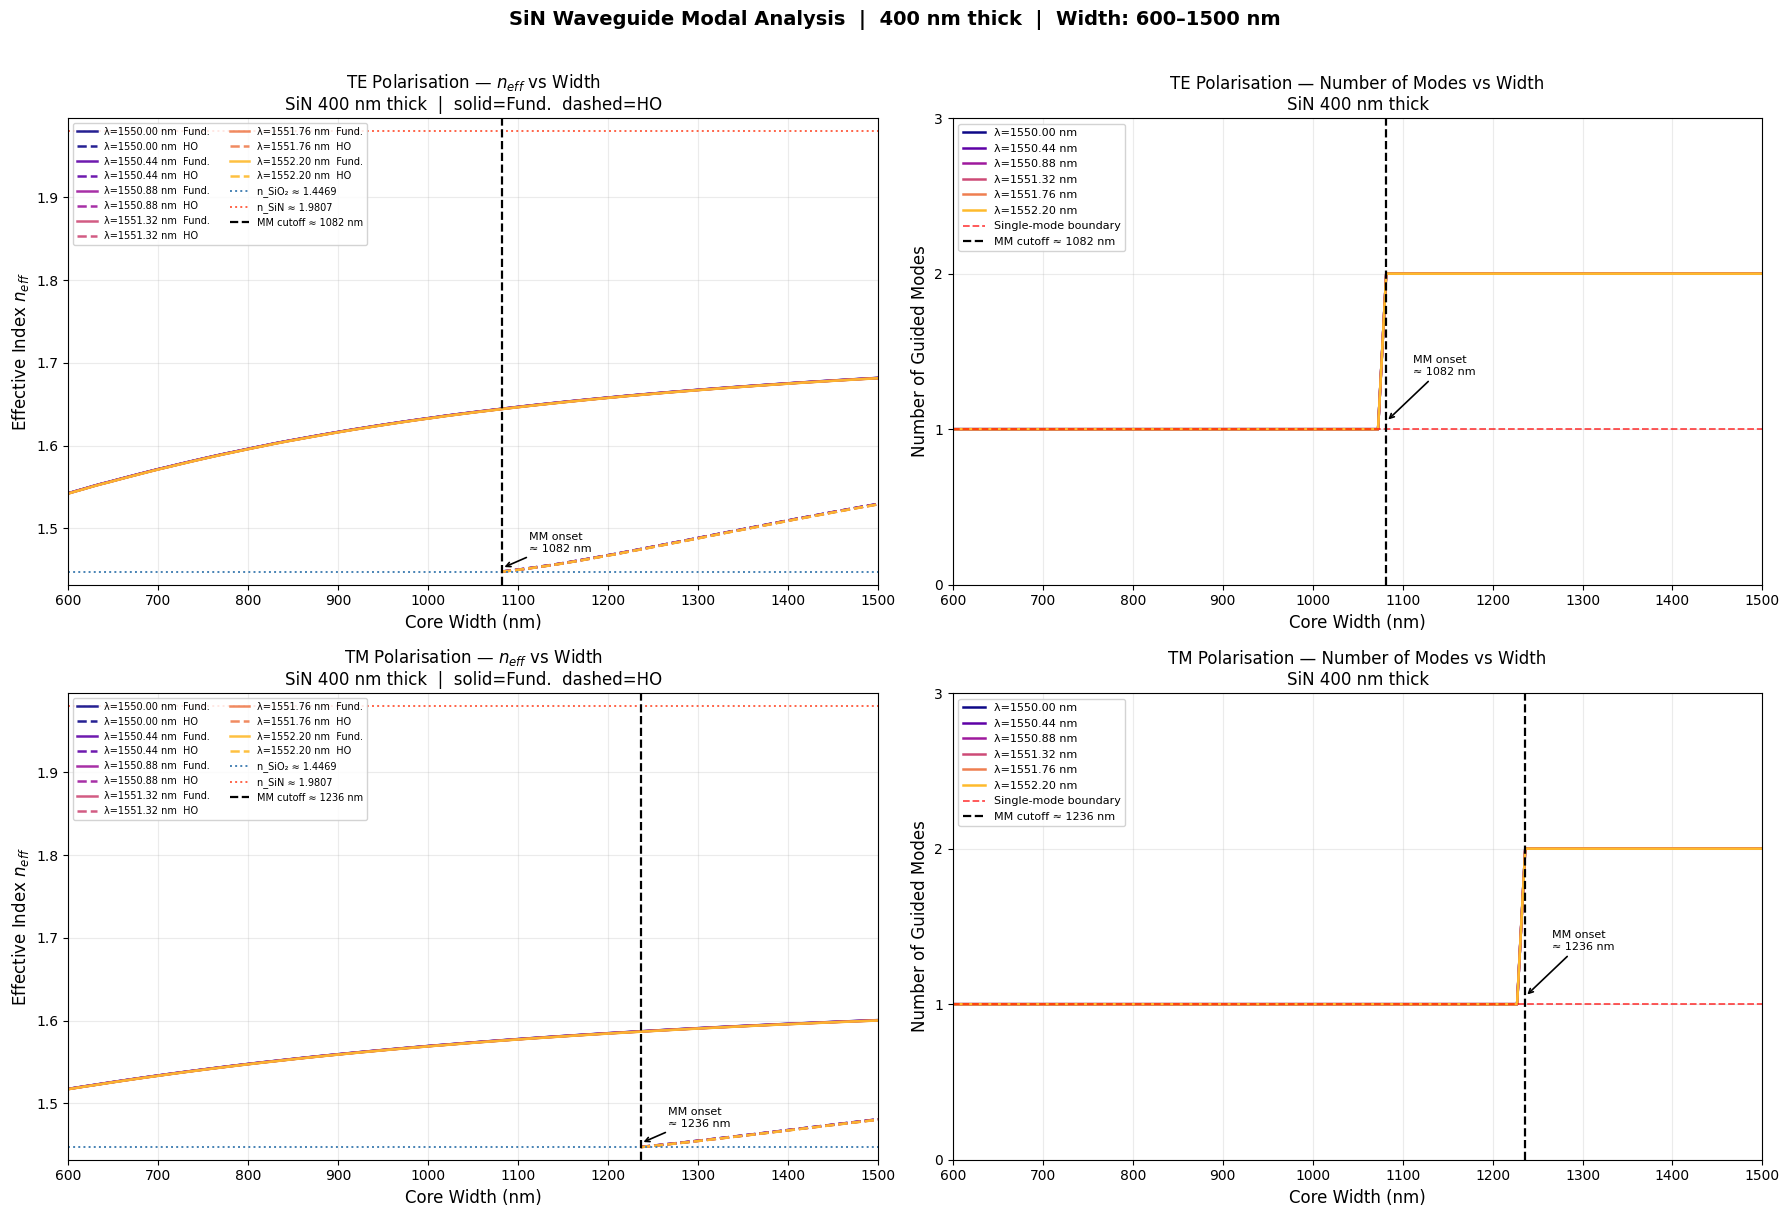

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

colors      = plt.cm.plasma(np.linspace(0, 0.85, len(sweep_wavelength)))
linestyles  = ['-', '--']
mode_labels = ['Fund.', 'HO']

for pol_idx, pol_value in enumerate(['TE', 'TM']):

    n_clad_arr = np.array([n_SiO2(w) for w in sweep_wavelength])
    n_core_arr = np.array([n_SiN (w) for w in sweep_wavelength])

    # ── find cutoff width: first width where num_modes_count  > 1 for ANY wavelength ──
    cutoff_width_idx = None
    for width_idx in range(len(sweep_width)):
        for wave_idx in range(len(sweep_wavelength)):
            if num_modes_count [pol_idx][wave_idx][width_idx] > 1:
                cutoff_width_idx = width_idx
                break
        if cutoff_width_idx is not None:
            break

    cutoff_width_nm = sweep_width[cutoff_width_idx] * 1e3 if cutoff_width_idx is not None else None

    # ── left column: neff vs width ──────────────────────────────────────────────
    ax_neff = axes[pol_idx, 0]

    for wave_idx, wave_values in enumerate(sweep_wavelength):
        for mode_idx in range(2):

            neff_aligned    = np.full(len(sweep_width), np.nan)
            sparse_cursor   = 0

            for width_idx in range(len(sweep_width)):
                if num_modes_count [pol_idx][wave_idx][width_idx] > mode_idx:
                    if sparse_cursor < len(neff[pol_idx][wave_idx][mode_idx]):
                        neff_aligned[width_idx] = neff[pol_idx][wave_idx][mode_idx][sparse_cursor]
                        sparse_cursor += 1

            if not np.all(np.isnan(neff_aligned)):
                ax_neff.plot(
                    sweep_width * 1e3,
                    neff_aligned,
                    color     = colors[wave_idx],
                    linestyle = linestyles[mode_idx],
                    linewidth = 1.8,
                    alpha     = 0.9,
                    label     = f"λ={wave_values*1e3:.2f} nm  {mode_labels[mode_idx]}"
                )

    # horizontal n bounds
    ax_neff.axhline(
        n_clad_arr[2], color='steelblue', linestyle=':', linewidth=1.4,
        label=f'n_SiO₂ ≈ {n_clad_arr[2]:.4f}'
    )
    ax_neff.axhline(
        n_core_arr[2], color='tomato', linestyle=':', linewidth=1.4,
        label=f'n_SiN ≈ {n_core_arr[2]:.4f}'
    )

    # vertical cutoff line
    if cutoff_width_nm is not None:
        ax_neff.axvline(
            cutoff_width_nm, color='black', linestyle='--', linewidth=1.6,
            label=f'MM cutoff ≈ {cutoff_width_nm:.0f} nm'
        )
        ax_neff.annotate(
            f'MM onset\n≈ {cutoff_width_nm:.0f} nm',
            xy         = (cutoff_width_nm, n_clad_arr[2] + 0.005),
            xytext     = (cutoff_width_nm + 30, n_clad_arr[2] + 0.025),
            fontsize   = 8,
            color      = 'black',
            arrowprops = dict(arrowstyle='->', color='black', lw=1.2)
        )

    ax_neff.set_ylim(n_clad_arr.min() - 0.015, n_core_arr.max() + 0.015)
    ax_neff.set_xlim(sweep_width[0]*1e3, sweep_width[-1]*1e3)
    ax_neff.set_xlabel("Core Width (nm)",            fontsize=12)
    ax_neff.set_ylabel("Effective Index $n_{eff}$",  fontsize=12)
    ax_neff.set_title(
        f"{pol_value} Polarisation — $n_{{eff}}$ vs Width\n"
        f"SiN {core_thickness*1e3:.0f} nm thick  |  solid=Fund.  dashed=HO",
        fontsize=12
    )
    ax_neff.legend(fontsize=7, ncol=2, loc='upper left', framealpha=0.85)
    ax_neff.grid(True, alpha=0.25)

    # ── right column: number of modes vs width ─────────────────────────────────
    ax_nm = axes[pol_idx, 1]

    for wave_idx, wave_values in enumerate(sweep_wavelength):
        ax_nm.plot(
            sweep_width * 1e3,
            num_modes_count [pol_idx][wave_idx],
            color     = colors[wave_idx],
            linewidth = 1.8,
            label     = f"λ={wave_values*1e3:.2f} nm"
        )

    ax_nm.axhline(
        1, color='red', linestyle='--', linewidth=1.3,
        alpha=0.7, label='Single-mode boundary'
    )

    # vertical cutoff line
    if cutoff_width_nm is not None:
        ax_nm.axvline(
            cutoff_width_nm, color='black', linestyle='--', linewidth=1.6,
            label=f'MM cutoff ≈ {cutoff_width_nm:.0f} nm'
        )
        ax_nm.annotate(
            f'MM onset\n≈ {cutoff_width_nm:.0f} nm',
            xy         = (cutoff_width_nm, 1.05),
            xytext     = (cutoff_width_nm + 30, 1.35),
            fontsize   = 8,
            color      = 'black',
            arrowprops = dict(arrowstyle='->', color='black', lw=1.2)
        )

    max_modes_val = max(max(num_modes_count [pol_idx][wi]) for wi in range(len(sweep_wavelength)))

    ax_nm.set_xlim(sweep_width[0]*1e3, sweep_width[-1]*1e3)
    ax_nm.set_ylim(0, max_modes_val + 1)
    ax_nm.set_yticks(range(0, max_modes_val + 2))
    ax_nm.set_xlabel("Core Width (nm)",        fontsize=12)
    ax_nm.set_ylabel("Number of Guided Modes", fontsize=12)
    ax_nm.set_title(
        f"{pol_value} Polarisation — Number of Modes vs Width\n"
        f"SiN {core_thickness*1e3:.0f} nm thick",
        fontsize=12
    )
    ax_nm.legend(fontsize=8, loc='upper left', framealpha=0.85)
    ax_nm.grid(True, alpha=0.25)

plt.suptitle(
    f"SiN Waveguide Modal Analysis  |  {core_thickness*1e3:.0f} nm thick  |  "
    f"Width: {sweep_width[0]*1e3:.0f}–{sweep_width[-1]*1e3:.0f} nm",
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(str(data_dir / f"{version_name}_modal_analysis.png"), dpi=150, bbox_inches='tight')
plt.show()

Single-mode assured width selected: 1000.0 nm  (index 52)


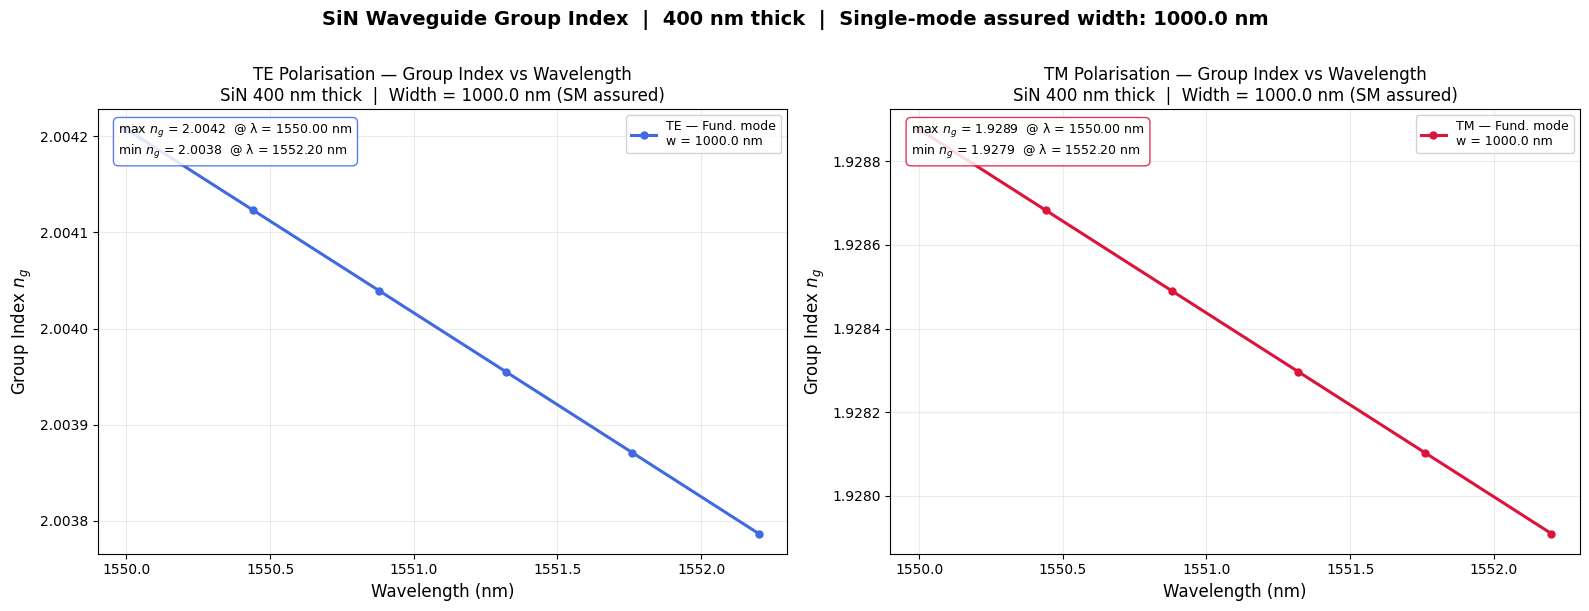

In [24]:
# ── Find single-mode assured width: one step below the MM cutoff ──────────────
cutoff_indices = []
for pol_idx in range(2):
    for width_idx in range(len(sweep_width)):
        for wave_idx in range(len(sweep_wavelength)):
            if num_modes_count [pol_idx][wave_idx][width_idx] > 1:
                cutoff_indices.append(width_idx)
                break
        else:
            continue
        break

safe_width_idx = min(cutoff_indices) - 1
# safe_width_nm  = sweep_width[safe_width_idx] * 1e3
safe_width_nm = 1.0 * 1e3
print(f"Single-mode assured width selected: {safe_width_nm:.1f} nm  (index {safe_width_idx})")

# ── Plot group index vs wavelength ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_pol = ['royalblue', 'crimson']


neff_sio2_TE_1550 = float(
    sim_data_arr_modes[0][safe_width_idx].modes_raw.n_complex.abs
    .isel(mode_index=0).squeeze().values[
        np.argmin(np.abs(sweep_wavelength - 1.550))
    ]
)
neff_sio2_TM_1550 = float(
    sim_data_arr_modes[1][safe_width_idx].modes_raw.n_complex.abs
    .isel(mode_index=0).squeeze().values[
        np.argmin(np.abs(sweep_wavelength - 1.550))
    ]
)

for pol_idx, pol_value in enumerate(['TE', 'TM']):

    ax = axes[pol_idx]

    n_group_values = (
        sim_data_arr_modes[pol_idx][safe_width_idx]
        .modes_raw
        .n_group
        .isel(mode_index=0)
        .squeeze()
        .values
    )

    ax.plot(
        sweep_wavelength * 1e3,
        n_group_values,
        color      = colors_pol[pol_idx],
        linewidth  = 2.2,
        marker     = 'o',
        markersize = 5,
        label      = f"{pol_value} — Fund. mode\nw = {safe_width_nm:.1f} nm"
    )

    # ── min/max as text box in axes coordinates (no arrows) ───────────────────
    ng_min_idx = np.argmin(n_group_values)
    ng_max_idx = np.argmax(n_group_values)

    stats_text = (
        f"max $n_g$ = {n_group_values[ng_max_idx]:.4f}  "
        f"@ λ = {sweep_wavelength[ng_max_idx]*1e3:.2f} nm\n"
        f"min $n_g$ = {n_group_values[ng_min_idx]:.4f}  "
        f"@ λ = {sweep_wavelength[ng_min_idx]*1e3:.2f} nm"
    )
    ax.text(
        0.03, 0.97, stats_text,
        transform            = ax.transAxes,
        fontsize             = 9,
        verticalalignment    = 'top',
        horizontalalignment  = 'left',
        bbox                 = dict(boxstyle='round,pad=0.4', facecolor='white',
                                    edgecolor=colors_pol[pol_idx], alpha=0.85)
    )

    ax.set_xlabel("Wavelength (nm)",   fontsize=12)
    ax.set_ylabel("Group Index $n_g$", fontsize=12)
    ax.set_title(
        f"{pol_value} Polarisation — Group Index vs Wavelength\n"
        f"SiN {core_thickness*1e3:.0f} nm thick  |  Width = {safe_width_nm:.1f} nm (SM assured)",
        fontsize=12
    )
    ax.legend(fontsize=9, loc='upper right', framealpha=0.85)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(sweep_wavelength[0]*1e3 - 0.1, sweep_wavelength[-1]*1e3 + 0.1)

plt.suptitle(
    f"SiN Waveguide Group Index  |  {core_thickness*1e3:.0f} nm thick  |  "
    f"Single-mode assured width: {safe_width_nm:.1f} nm",
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(str(data_dir / f"{version_name}_group_index.png"), dpi=150, bbox_inches='tight')
plt.show()


────────────────────────────────────────────────────────────────────
  Ring Resonator Design — TE Polarization | FSR target = 2.2 nm | Width = 1000.0 nm
────────────────────────────────────────────────────────────────────
+-----------+---------+-----+---------+----------+-----------------+
|  λ (nm)   |   n_g   |  m  | R (µm)  | 2πR (µm) | FSR_actual (nm) |
|===========|=========|=====|=========|==========|=================|
| 1550.0000 | 2.00421 | 352 | 86.8349 | 545.6000 |     2.1971      |
| 1550.4400 | 2.00412 | 352 | 86.8596 | 545.7549 |     2.1978      |
| 1550.8800 | 2.00404 | 352 | 86.8842 | 545.9098 |     2.1985      |
| 1551.3200 | 2.00396 | 352 | 86.9089 | 546.0646 |     2.1992      |
| 1551.7600 | 2.00387 | 352 | 86.9335 | 546.2195 |     2.1999      |
| 1552.2000 | 2.00379 | 352 | 86.9582 | 546.3744 |     2.2007      |
+-----------+---------+-----+---------+----------+-----------------+

────────────────────────────────────────────────────────────────────
  Ring Resonator 

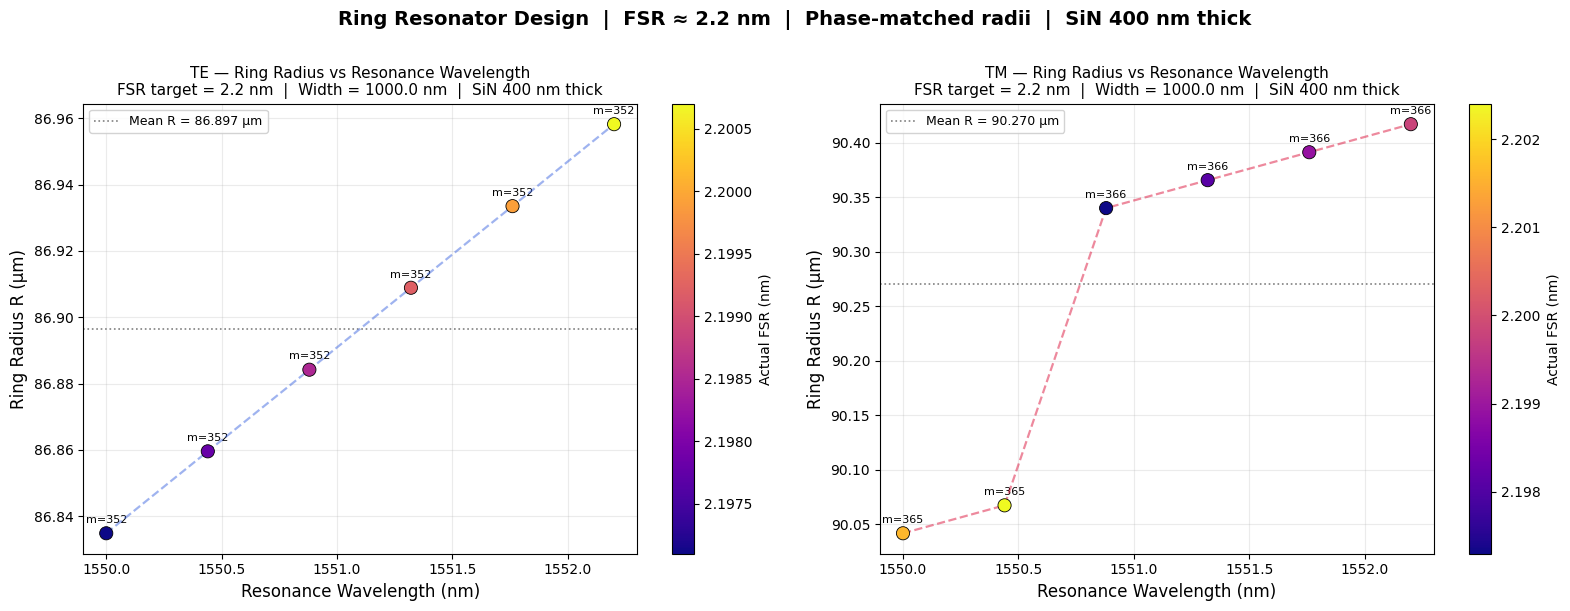

In [25]:
# ── FSR Ring Resonator Design: R vs resonance wavelength ─────────────────────
# FSR = λ² / (n_g * 2π * R)  →  R = λ² / (n_g * FSR_target * 2π)
# Phase matching: 2π*R = m*λ  →  m = round(2π*R / λ),  then R_exact = m*λ / (2π)
# Iterate m until FSR is closest to target

FSR_target_nm = 2.2                          # target FSR in nm
FSR_target    = FSR_target_nm * 1e-3         # convert to µm (same units as wavelength)

# ── Extract n_group for both polarizations at safe_width_idx ─────────────────
n_group_TE = (
    sim_data_arr_modes[0][safe_width_idx]
    .modes_raw.n_group
    .isel(mode_index=0).squeeze().values
)

n_group_TM = (
    sim_data_arr_modes[1][safe_width_idx]
    .modes_raw.n_group
    .isel(mode_index=0).squeeze().values
)

# ── Compute phase-matched radius for each wavelength and polarization ─────────
# Returns: R_exact (µm), m (integer), FSR_actual (nm)
def compute_ring_radius(wavelength_um, n_g, FSR_target_um):
    # Step 1: first estimate of R from FSR formula
    R_estimate = wavelength_um**2 / (n_g * FSR_target_um * 2 * np.pi)
    # Step 2: find integer m satisfying phase matching 2πR = mλ
    m = round(2 * np.pi * R_estimate / wavelength_um)
    # Step 3: exact R from phase matching condition
    R_exact = m * wavelength_um / (2 * np.pi)
    # Step 4: actual FSR with this exact R
    FSR_actual_um = wavelength_um**2 / (n_g * 2 * np.pi * R_exact)
    FSR_actual_nm = FSR_actual_um * 1e3
    return R_exact, m, FSR_actual_nm

results_TE = []
results_TM = []

for wave_idx, wave_values in enumerate(sweep_wavelength):
    wl_nm = wave_values * 1e3                # µm → nm for display

    # TE
    R_TE, m_TE, FSR_TE = compute_ring_radius(wave_values, n_group_TE[wave_idx], FSR_target)
    results_TE.append({
        'λ (nm)'        : f"{wl_nm:.4f}",
        'n_g'           : f"{n_group_TE[wave_idx]:.5f}",
        'm'             : m_TE,
        'R (µm)'        : f"{R_TE:.4f}",
        '2πR (µm)'      : f"{2*np.pi*R_TE:.4f}",
        'FSR_actual (nm)': f"{FSR_TE:.4f}",
    })

    # TM
    R_TM, m_TM, FSR_TM = compute_ring_radius(wave_values, n_group_TM[wave_idx], FSR_target)
    results_TM.append({
        'λ (nm)'        : f"{wl_nm:.4f}",
        'n_g'           : f"{n_group_TM[wave_idx]:.5f}",
        'm'             : m_TM,
        'R (µm)'        : f"{R_TM:.4f}",
        '2πR (µm)'      : f"{2*np.pi*R_TM:.4f}",
        'FSR_actual (nm)': f"{FSR_TM:.4f}",
    })

# ── Print tables ──────────────────────────────────────────────────────────────
def print_table(results, pol_label):
    headers = list(results[0].keys())
    col_w   = [max(len(h), max(len(str(r[h])) for r in results)) + 2 for h in headers]
    sep     = "+" + "+".join("-"*w for w in col_w) + "+"
    row_fmt = "|" + "|".join(f"{{:^{w}}}" for w in col_w) + "|"

    print(f"\n{'─'*len(sep)}")
    print(f"  Ring Resonator Design — {pol_label} | FSR target = {FSR_target_nm} nm"
          f" | Width = {safe_width_nm:.1f} nm")
    print(f"{'─'*len(sep)}")
    print(sep)
    print(row_fmt.format(*headers))
    print(sep.replace('-','=').replace('+','|'))
    for r in results:
        print(row_fmt.format(*[str(r[h]) for h in headers]))
    print(sep)

print_table(results_TE, "TE Polarization")
print_table(results_TM, "TM Polarization")

# ── Extract numeric arrays for plotting ───────────────────────────────────────
R_vals_TE  = np.array([float(r['R (µm)'])  for r in results_TE])
R_vals_TM  = np.array([float(r['R (µm)'])  for r in results_TM])
wl_nm_arr  = np.array([float(r['λ (nm)'])  for r in results_TE])
FSR_TE_arr = np.array([float(r['FSR_actual (nm)']) for r in results_TE])
FSR_TM_arr = np.array([float(r['FSR_actual (nm)']) for r in results_TM])

# ── Plot: Radius vs resonance wavelength ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, R_vals, FSR_arr, pol_value, color in zip(
    axes,
    [R_vals_TE,  R_vals_TM],
    [FSR_TE_arr, FSR_TM_arr],
    ['TE', 'TM'],
    ['royalblue', 'crimson']
):
    sc = ax.scatter(
        wl_nm_arr, R_vals,
        c          = FSR_arr,
        cmap       = 'plasma',
        s          = 90,
        zorder     = 5,
        edgecolors = 'black',
        linewidths = 0.6
    )
    ax.plot(
        wl_nm_arr, R_vals,
        color     = color,
        linewidth = 1.6,
        linestyle = '--',
        alpha     = 0.5,
        zorder    = 4
    )

    # annotate each point with its m value
    for i, (wl, R, m_val) in enumerate(zip(
        wl_nm_arr, R_vals,
        [r['m'] for r in (results_TE if pol_value=='TE' else results_TM)]
    )):
        ax.text(
            wl, R + (R_vals.max() - R_vals.min()) * 0.025,
            f"m={m_val}",
            fontsize            = 8,
            ha                  = 'center',
            color               = 'black'
        )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Actual FSR (nm)", fontsize=10)

    ax.axhline(R_vals.mean(), color='gray', linestyle=':', linewidth=1.2,
               label=f"Mean R = {R_vals.mean():.3f} µm")

    ax.set_xlabel("Resonance Wavelength (nm)", fontsize=12)
    ax.set_ylabel("Ring Radius R (µm)",        fontsize=12)
    ax.set_title(
        f"{pol_value} — Ring Radius vs Resonance Wavelength\n"
        f"FSR target = {FSR_target_nm} nm  |  Width = {safe_width_nm:.1f} nm  |  "
        f"SiN {core_thickness*1e3:.0f} nm thick",
        fontsize=11
    )
    ax.legend(fontsize=9, loc='upper left', framealpha=0.85)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(wl_nm_arr[0] - 0.1, wl_nm_arr[-1] + 0.1)

plt.suptitle(
    f"Ring Resonator Design  |  FSR ≈ {FSR_target_nm} nm  |  "
    f"Phase-matched radii  |  SiN {core_thickness*1e3:.0f} nm thick",
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(str(data_dir / f"{version_name}_ring_radius_FSR.png"), dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# ── New parameters for double-strip gap sweep ─────────────────────────────────
# Reuses: sweep_wavelength, sweep_freq, core_thickness, n_SiN, n_SiO2,
#         core_medium, cladd_medium definitions, data_dir, web configuration

gap_points      = 50                                        # number of gap points
sweep_gap       = np.linspace(0.400, 0.800, gap_points)    # gap sweep 600–800 nm in µm
fixed_width     = safe_width_nm * 1e-3                      # 1.0727 µm from single-mode analysis
version_name_gap = "SiN_sim_400_gap_sweep_V2"

# ── Double-strip modal simulation function ────────────────────────────────────
def build_gap_sweep_simulation(
    core_width      = fixed_width,
    core_thickness  = 0.400,
    sweep_gap       = np.linspace(0.600, 0.800, 20),
    wavelength      = np.array([1.550]),
    version_name    = "SiN_gap_sweep"
):
    base_path = f"data_STRp_SiN_mode_analysis/{version_name}"
    os.makedirs(base_path, exist_ok=True)

    freqs = td.C_0 / wavelength

    core_medium = td.Medium(
        name        = 'core_SiN_medium',
        permittivity= 1.99**2,
    )
    cladd_medium = td.Medium(
        name        = 'cladd_SiO2_medium',
        permittivity= 1.4469404291704726**2,
    )

    # sim_data_arr[pol_idx][gap_idx] → ModeSimulationData
    # pol 0 = TE (even+odd symmetric), pol 1 = TM (even+odd antisymmetric)
    sim_data_arr = [[], []]
    sim_arr      = [[], []]
    estimate     = 0

    for (pol_idx, pol_value) in enumerate(['TE', 'TM']):

        pol_folder = f"{base_path}/pol{pol_value}"
        os.makedirs(pol_folder, exist_ok=True)

        for (gap_idx, gap_value) in enumerate(sweep_gap):

            filename = f"{pol_folder}/gap_{int(gap_value*1000)}.hdf5"

            # ── Two waveguides: centered at ±(width/2 + gap/2) along y ───────
            # waveguide 1: center at  +(core_width/2 + gap_value/2)
            # waveguide 2: center at  -(core_width/2 + gap_value/2)
            center_offset = core_width / 2 + gap_value / 2

            waveguide_1 = td.Structure(
                geometry = td.Box(
                    center = [0,  center_offset, 0],
                    size   = [td.inf, core_width, core_thickness]
                ),
                name   = 'waveguide_1',
                medium = core_medium
            )

            waveguide_2 = td.Structure(
                geometry = td.Box(
                    center = [0, -center_offset, 0],
                    size   = [td.inf, core_width, core_thickness]
                ),
                name   = 'waveguide_2',
                medium = core_medium
            )

            # ── Simulation domain ─────────────────────────────────────────────
            # Domain y: must contain both waveguides + cladding margin
            # total y span needed: 2*(width + gap/2) + margins ~ 2*width + gap + 4µm
            domain_y = 2 * core_width + gap_value + 4.0

            sim_arr[pol_idx].append(td.ModeSimulation(
                freqs     = freqs,
                mode_spec = td.ModeSpec(
                    target_neff     = 1.99,
                    num_modes       = 4,        # need at least even + odd supermode
                    sort_spec       = {
                        'filter_reference' : 0,
                        'filter_order'     : 'over',
                        'sort_order'       : 'ascending',
                        'track_freq'       : 'central'
                    },
                    group_index_step = True,
                ),
                size      = [7, domain_y, 7],
                grid_spec = td.GridSpec(
                    grid_x     = td.AutoGrid(min_steps_per_wvl=15),
                    grid_y     = td.AutoGrid(min_steps_per_wvl=15),
                    grid_z     = td.AutoGrid(min_steps_per_wvl=15),
                    wavelength = 1.550,
                ),
                version    = '2.10.1',
                medium     = cladd_medium,
                sources    = [],
                monitors   = [],
                structures = [waveguide_1, waveguide_2],
                # No symmetry: double strip breaks y-symmetry between even/odd supermodes
                # z-symmetry still valid for TE/TM separation
                symmetry   = [0, 0,  1] if pol_value == 'TE' else [0, 0, -1],
                plane      = td.Box(center=[0, 0, 0], size=[0, domain_y, 7])
            ))

            if os.path.exists(filename):
                sim_data_arr[pol_idx].append(
                    td.ModeSimulationData.from_file(Path(filename))
                )
            else:
                task_name = f"{version_name}_P{pol_value}_G{int(gap_value*1000)}"
                job       = web.Job(
                    simulation = sim_arr[pol_idx][gap_idx],
                    task_name  = task_name
                )
                sim_data_arr[pol_idx].append(job.run())
                sim_data_arr[pol_idx][gap_idx].to_file(filename)

                Job      = web.Job(
                    simulation = sim_arr[pol_idx][gap_idx],
                    task_name  = "cost_estimate"
                )
                estimate += Job.estimate_cost()

    print(f"Estimated Maximum Cost: {estimate}")
    return sim_data_arr, sim_arr


# ── Run the gap sweep ─────────────────────────────────────────────────────────
sim_data_arr_gap, sim_arr_gap = build_gap_sweep_simulation(
    core_width     = fixed_width,
    core_thickness = core_thickness,
    sweep_gap      = sweep_gap,
    wavelength     = sweep_wavelength,
    version_name   = version_name_gap
)

21:54:39 Hora est. Pacífico, Sudamérica WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

                                        WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

                                        WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

21:54:40 Hora est. Pacífico, Sudamérica WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

                                        WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

...

                                        WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

                                        WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

                                        WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

                                        WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

Estimated Maximum Cost: 0



──────────────────────────────────────────────────────────────
  Critical Coupling Analysis — TE Polarisation
  λ₀ = 1550.0 nm  |  FWHM = 0.20 nm  |  FSR = 2.2 nm
  Width = 1000.0 nm  |  Thickness = 400 nm
──────────────────────────────────────────────────────────────
  Group index  n_g                     2.004207
  Q factor                             7750.0
  Finesse  F                           11.00
──────────────────────────────────────────────────────────────
  Round-trip field transmission  a     0.867345
  Round-trip power transmission  a²    0.752287
  Round-trip power loss (dB)           1.2362 dB
  Propagation loss  α                  22.6570 dB/cm
──────────────────────────────────────────────────────────────
  Self-coupling coeff.  t  (= a)       0.867345
  Cross-coupling coeff.  κ             0.497708
  Power coupling ratio  κ²             0.247713
──────────────────────────────────────────────────────────────
  Ring radius  R                       86.8349 µm
  Round-tr

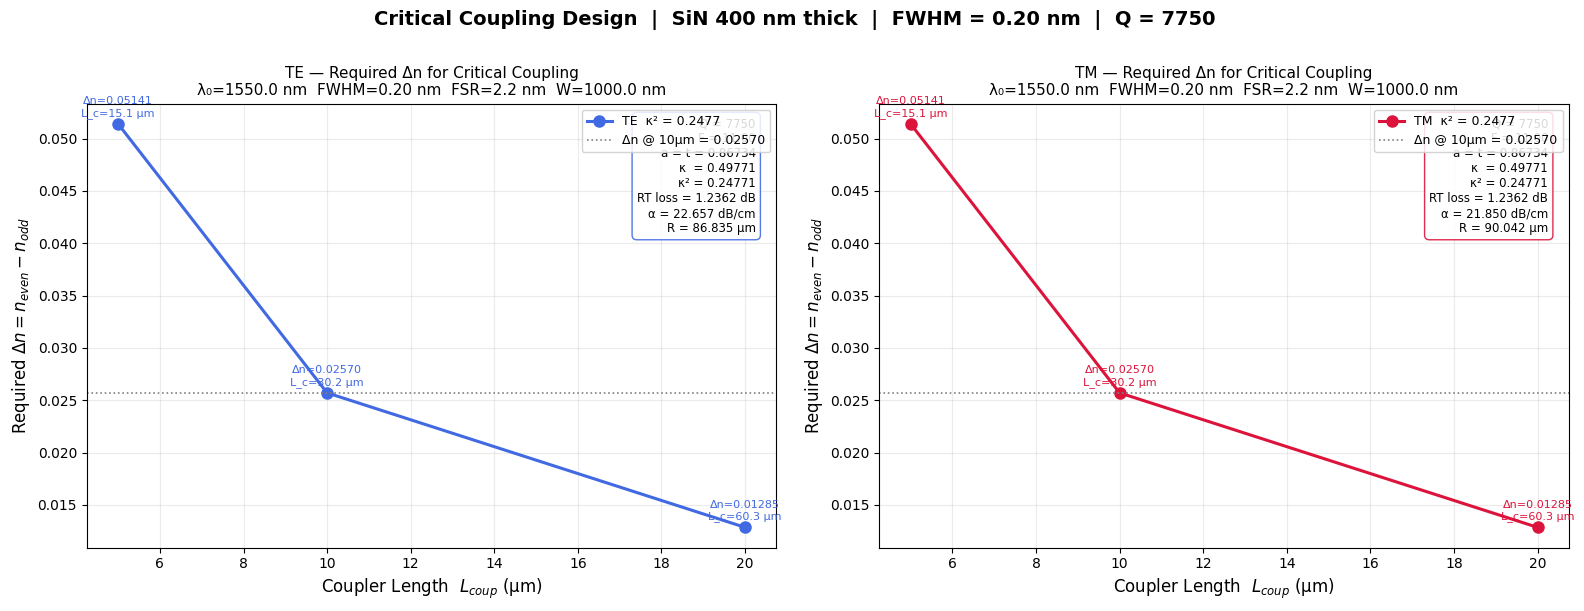

In [27]:
# ── Critical Coupling Calculations for SiN Ring Resonator ────────────────────
# All formulas follow the standard coupled-mode theory / transfer matrix approach
# as used in Lumerical's ring resonator methodology.
#
# Definitions:
#   λ₀        = central resonance wavelength
#   FWHM      = full-width at half-maximum of the resonance
#   Q         = quality factor
#   n_g       = group index at fixed_width (safe_width_idx)
#   FSR       = free spectral range
#   L = 2πR   = round-trip circumference (from ring design above)
#   α         = power round-trip loss coefficient (field: α_field = α/2)
#   t         = self-coupling coefficient  (field transmission past coupler)
#   κ         = cross-coupling coefficient (κ² + t² = 1, lossless coupler)
#   Δn        = n_even - n_odd from double-strip supermode splitting
#   L_c       = coupling length = λ / (2·Δn)
#   κ²        = sin²(π·L_coup / (2·L_c))  for a straight coupler of length L_coup
#
# Critical coupling condition:  t = a  (self-coupling = round-trip field attenuation)
# where a = exp(-α_field · L)  is the round-trip field transmission
#
# From FWHM and FSR:
#   Q         = λ₀ / FWHM
#   finesse F = FSR / FWHM  = π·√(t·a) / (1 - t·a)  ← Airy function result
#   At critical coupling t = a, so:
#   F         = π·a / (1 - a²)
#   Solving:   a² - (π/F)·a - 1 = 0  → take physical root 0 < a < 1
#
# Then:
#   t         = a                (critical coupling)
#   κ²        = 1 - t²
#   κ         = sqrt(κ²)
#   α_field   = -ln(a) / L      (field loss per unit length)
#   α_power   = 2·α_field       (power loss per unit length, dB/m = α_power·4.343e3)
#
# Δn required for a given coupler geometry:
#   For a directional coupler of length L_coup:
#   κ = sin(π·L_coup / (2·L_c)) → L_c = π·L_coup / (2·arcsin(κ))
#   Δn = λ / (2·L_c)
# ─────────────────────────────────────────────────────────────────────────────

lambda_0_um  = 1.550          # central wavelength µm
FWHM_nm      = 0.2            # target FWHM nm
FWHM_um      = FWHM_nm * 1e-3 # µm

# ── Pull n_group at λ₀ for both polarizations ─────────────────────────────────
# sweep_wavelength index closest to 1550 nm
lambda_0_idx = np.argmin(np.abs(sweep_wavelength - lambda_0_um))

n_g_TE = float(
    sim_data_arr_modes[0][safe_width_idx]
    .modes_raw.n_group
    .isel(mode_index=0).squeeze().values[lambda_0_idx]
)
n_g_TM = float(
    sim_data_arr_modes[1][safe_width_idx]
    .modes_raw.n_group
    .isel(mode_index=0).squeeze().values[lambda_0_idx]
)

# ── Ring circumference L at λ₀ from ring design (TE, closest to target FSR) ──
# results_TE[lambda_0_idx] holds R in µm for the resonance closest to λ₀
R_ring_TE_um = float(results_TE[lambda_0_idx]['R (µm)'])
R_ring_TM_um = float(results_TM[lambda_0_idx]['R (µm)'])
L_ring_TE    = 2 * np.pi * R_ring_TE_um   # round-trip length µm
L_ring_TM    = 2 * np.pi * R_ring_TM_um

# ── Core calculations ─────────────────────────────────────────────────────────
def critical_coupling_analysis(n_g, lambda_0_um, FWHM_um, L_ring_um, FSR_target_nm, pol_label):

    FSR_um   = FSR_target_nm * 1e-3

    # ── Q factor ──────────────────────────────────────────────────────────────
    Q        = lambda_0_um / FWHM_um

    # ── Finesse ───────────────────────────────────────────────────────────────
    F        = FSR_um / FWHM_um

    # ── Round-trip field attenuation 'a' from finesse at critical coupling ────
    # F = π·a / (1 - a²)  →  a² + (π/F)·a - 1 = 0  (note sign: rearranged)
    # Quadratic: a² - (π/F)·a - 1 = 0  has no root in (0,1)
    # Correct rearrangement: F(1-a²) = π·a → F·a² + π·a - F = 0
    # a = (-π + sqrt(π² + 4F²)) / (2F)   ← positive physical root
    a        = (-np.pi + np.sqrt(np.pi**2 + 4 * F**2)) / (2 * F)

    # ── Self-coupling and cross-coupling coefficients ─────────────────────────
    t        = a                          # critical coupling: t = a
    kappa_sq = 1 - t**2                   # power coupling  κ²
    kappa    = np.sqrt(kappa_sq)          # field coupling  κ

    # ── Round-trip power loss ─────────────────────────────────────────────────
    a_sq          = a**2                  # round-trip power transmission
    loss_rt_dB    = -10 * np.log10(a_sq) # round-trip power loss in dB
    alpha_field   = -np.log(a) / L_ring_um          # field loss µm⁻¹
    alpha_power   = 2 * alpha_field                  # power loss µm⁻¹
    alpha_dB_cm   = alpha_power * 10 * np.log10(np.e) * 1e4  # dB/cm

    # ── Δn required for the directional coupler ───────────────────────────────
    # The coupler bends into the ring: effective straight coupling length L_coup
    # A standard estimate for a ring coupler is L_coup ≈ R·θ where θ is the
    # coupling angle. For a first-order estimate we use L_coup = λ₀ / (2·Δn_est)
    # which is the self-consistent definition. Solve instead from:
    #   κ = sin(π / 2 · (L_coup / L_c))  with L_c = λ / (2·Δn)
    # For a point coupler (L_coup → 0), κ² ≈ (π·L_coup·Δn / λ)²
    # More practically: given κ², the required Δn for a coupler of length L_coup
    # We provide Δn for three representative L_coup values.
    L_coup_values_um = np.array([5.0, 10.0, 20.0])   # µm, representative lengths

    delta_n_values = []
    L_c_values     = []
    for L_coup in L_coup_values_um:
        # κ = sin(π·L_coup / (2·L_c))  →  L_c = π·L_coup / (2·arcsin(κ))
        if kappa <= 1.0:
            L_c   = np.pi * L_coup / (2 * np.arcsin(kappa))
            Dn    = lambda_0_um / (2 * L_c)
        else:
            L_c   = np.nan
            Dn    = np.nan
        L_c_values.append(L_c)
        delta_n_values.append(Dn)

    # ── Effective refractive index at λ₀ (from n_group via dispersion approx) ─
    n_eff_approx = n_g   # for a first-order estimate at a single wavelength

    return {
        'pol'              : pol_label,
        'n_g'              : n_g,
        'Q'                : Q,
        'Finesse'          : F,
        'a (field trans.)' : a,
        't (self-coup.)'   : t,
        'κ (cross-coup.)'  : kappa,
        'κ² (power coup.)' : kappa_sq,
        'a² (RT power tr.)': a_sq,
        'RT loss (dB)'     : loss_rt_dB,
        'α_power (dB/cm)'  : alpha_dB_cm,
        'R_ring (µm)'      : L_ring_um / (2*np.pi),
        'L_ring (µm)'      : L_ring_um,
        'L_coup values (µm)': L_coup_values_um,
        'L_c values (µm)'  : np.array(L_c_values),
        'Δn values'        : np.array(delta_n_values),
    }

res_TE = critical_coupling_analysis(n_g_TE, lambda_0_um, FWHM_um, L_ring_TE, FSR_target_nm, 'TE')
res_TM = critical_coupling_analysis(n_g_TM, lambda_0_um, FWHM_um, L_ring_TM, FSR_target_nm, 'TM')

# ── Print summary table ───────────────────────────────────────────────────────
def print_critical_coupling_table(res):
    sep = "─" * 62
    print(f"\n{sep}")
    print(f"  Critical Coupling Analysis — {res['pol']} Polarisation")
    print(f"  λ₀ = {lambda_0_um*1e3:.1f} nm  |  FWHM = {FWHM_nm:.2f} nm  "
          f"|  FSR = {FSR_target_nm:.1f} nm")
    print(f"  Width = {safe_width_nm:.1f} nm  |  Thickness = {core_thickness*1e3:.0f} nm")
    print(sep)
    print(f"  {'Group index  n_g':<35s}  {res['n_g']:.6f}")
    print(f"  {'Q factor':<35s}  {res['Q']:.1f}")
    print(f"  {'Finesse  F':<35s}  {res['Finesse']:.2f}")
    print(sep)
    print(f"  {'Round-trip field transmission  a':<35s}  {res['a (field trans.)'  ]:.6f}")
    print(f"  {'Round-trip power transmission  a²':<35s}  {res['a² (RT power tr.)']:.6f}")
    print(f"  {'Round-trip power loss (dB)':<35s}  {res['RT loss (dB)']:.4f} dB")
    print(f"  {'Propagation loss  α':<35s}  {res['α_power (dB/cm)']:.4f} dB/cm")
    print(sep)
    print(f"  {'Self-coupling coeff.  t  (= a)':<35s}  {res['t (self-coup.)']:.6f}")
    print(f"  {'Cross-coupling coeff.  κ':<35s}  {res['κ (cross-coup.)']:.6f}")
    print(f"  {'Power coupling ratio  κ²':<35s}  {res['κ² (power coup.)']:.6f}")
    print(sep)
    print(f"  {'Ring radius  R':<35s}  {res['R_ring (µm)']:.4f} µm")
    print(f"  {'Round-trip length  L = 2πR':<35s}  {res['L_ring (µm)']:.4f} µm")
    print(sep)
    print(f"  Δn required vs coupler length  (κ = {res['κ (cross-coup.)']:.4f})")
    print(f"  {'L_coup (µm)':<14s}  {'L_c (µm)':<14s}  {'Δn required':<14s}")
    print(f"  {'─'*14}  {'─'*14}  {'─'*14}")
    for i, L_coup in enumerate(res['L_coup values (µm)']):
        print(f"  {L_coup:<14.1f}  "
              f"{res['L_c values (µm)'][i]:<14.4f}  "
              f"{res['Δn values'][i]:<14.6f}")
    print(sep)

print_critical_coupling_table(res_TE)
print_critical_coupling_table(res_TM)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_pol = ['royalblue', 'crimson']

for ax, res, color in zip(axes, [res_TE, res_TM], colors_pol):

    L_coup_arr = res['L_coup values (µm)']
    Dn_arr     = res['Δn values']

    ax.plot(
        L_coup_arr, Dn_arr,
        color=color, linewidth=2.2, marker='o', markersize=8,
        label=f"{res['pol']}  κ² = {res['κ² (power coup.)']:.4f}"
    )

    # annotate each point
    for L_c_val, Dn_val, L_coup in zip(res['L_c values (µm)'], Dn_arr, L_coup_arr):
        ax.text(
            L_coup, Dn_val + Dn_arr.max()*0.015,
            f"Δn={Dn_val:.5f}\nL_c={L_c_val:.1f} µm",
            fontsize=8, ha='center', color=color
        )

    # horizontal reference line at Δn for L_coup = 10 µm
    ax.axhline(
        Dn_arr[1], color='gray', linestyle=':', linewidth=1.2,
        label=f"Δn @ 10µm = {Dn_arr[1]:.5f}"
    )

    stats_text = (
        f"Q = {res['Q']:.0f}\n"
        f"F = {res['Finesse']:.2f}\n"
        f"a = t = {res['a (field trans.)'  ]:.5f}\n"
        f"κ  = {res['κ (cross-coup.)']:.5f}\n"
        f"κ² = {res['κ² (power coup.)']:.5f}\n"
        f"RT loss = {res['RT loss (dB)']:.4f} dB\n"
        f"α = {res['α_power (dB/cm)']:.3f} dB/cm\n"
        f"R = {res['R_ring (µm)']:.3f} µm"
    )
    ax.text(
        0.97, 0.97, stats_text,
        transform=ax.transAxes, fontsize=8.5,
        va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=color, alpha=0.9)
    )

    ax.set_xlabel("Coupler Length  $L_{coup}$ (µm)", fontsize=12)
    ax.set_ylabel("Required $\\Delta n = n_{even} - n_{odd}$",  fontsize=12)
    ax.set_title(
        f"{res['pol']} — Required Δn for Critical Coupling\n"
        f"λ₀={lambda_0_um*1e3:.1f} nm  FWHM={FWHM_nm:.2f} nm  "
        f"FSR={FSR_target_nm:.1f} nm  W={safe_width_nm:.1f} nm",
        fontsize=11
    )
    ax.legend(fontsize=9, loc='upper right', framealpha=0.85)
    ax.grid(True, alpha=0.25)

plt.suptitle(
    f"Critical Coupling Design  |  SiN {core_thickness*1e3:.0f} nm thick  |  "
    f"FWHM = {FWHM_nm:.2f} nm  |  Q = {res_TE['Q']:.0f}",
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(str(data_dir / f"{version_name}_critical_coupling.png"), dpi=150, bbox_inches='tight')
plt.show()

  WARNING [TE, L_coup=5µm]: Δn=0.05141 outside sweep range — extrapolated gap=400.0 nm
  WARNING [TE, L_coup=10µm]: Δn=0.02570 outside sweep range — extrapolated gap=400.0 nm
  WARNING [TM, L_coup=5µm]: Δn=0.05141 outside sweep range — extrapolated gap=400.0 nm
  WARNING [TM, L_coup=10µm]: Δn=0.02570 outside sweep range — extrapolated gap=400.0 nm

────────────────────────────────────────────────────────────────────────
  Critical Coupling Gap — TE Polarisation  |  λ₀=1550.0 nm  |  FWHM=0.20 nm
  κ = 0.49771   κ² = 0.24771   Q = 7750   F = 11.00
────────────────────────────────────────────────────────────────────────
  L_coup (µm)     Δn target       Gap (nm)      Δn @ gap        Δn error    
  ──────────────  ──────────────  ────────────  ──────────────  ────────────
  5.0             0.051406        400.00        0.016114        3.53e-02    
  10.0            0.025703        400.00        0.016114        9.59e-03    
  20.0            0.012851        462.81        0.012851        0.0

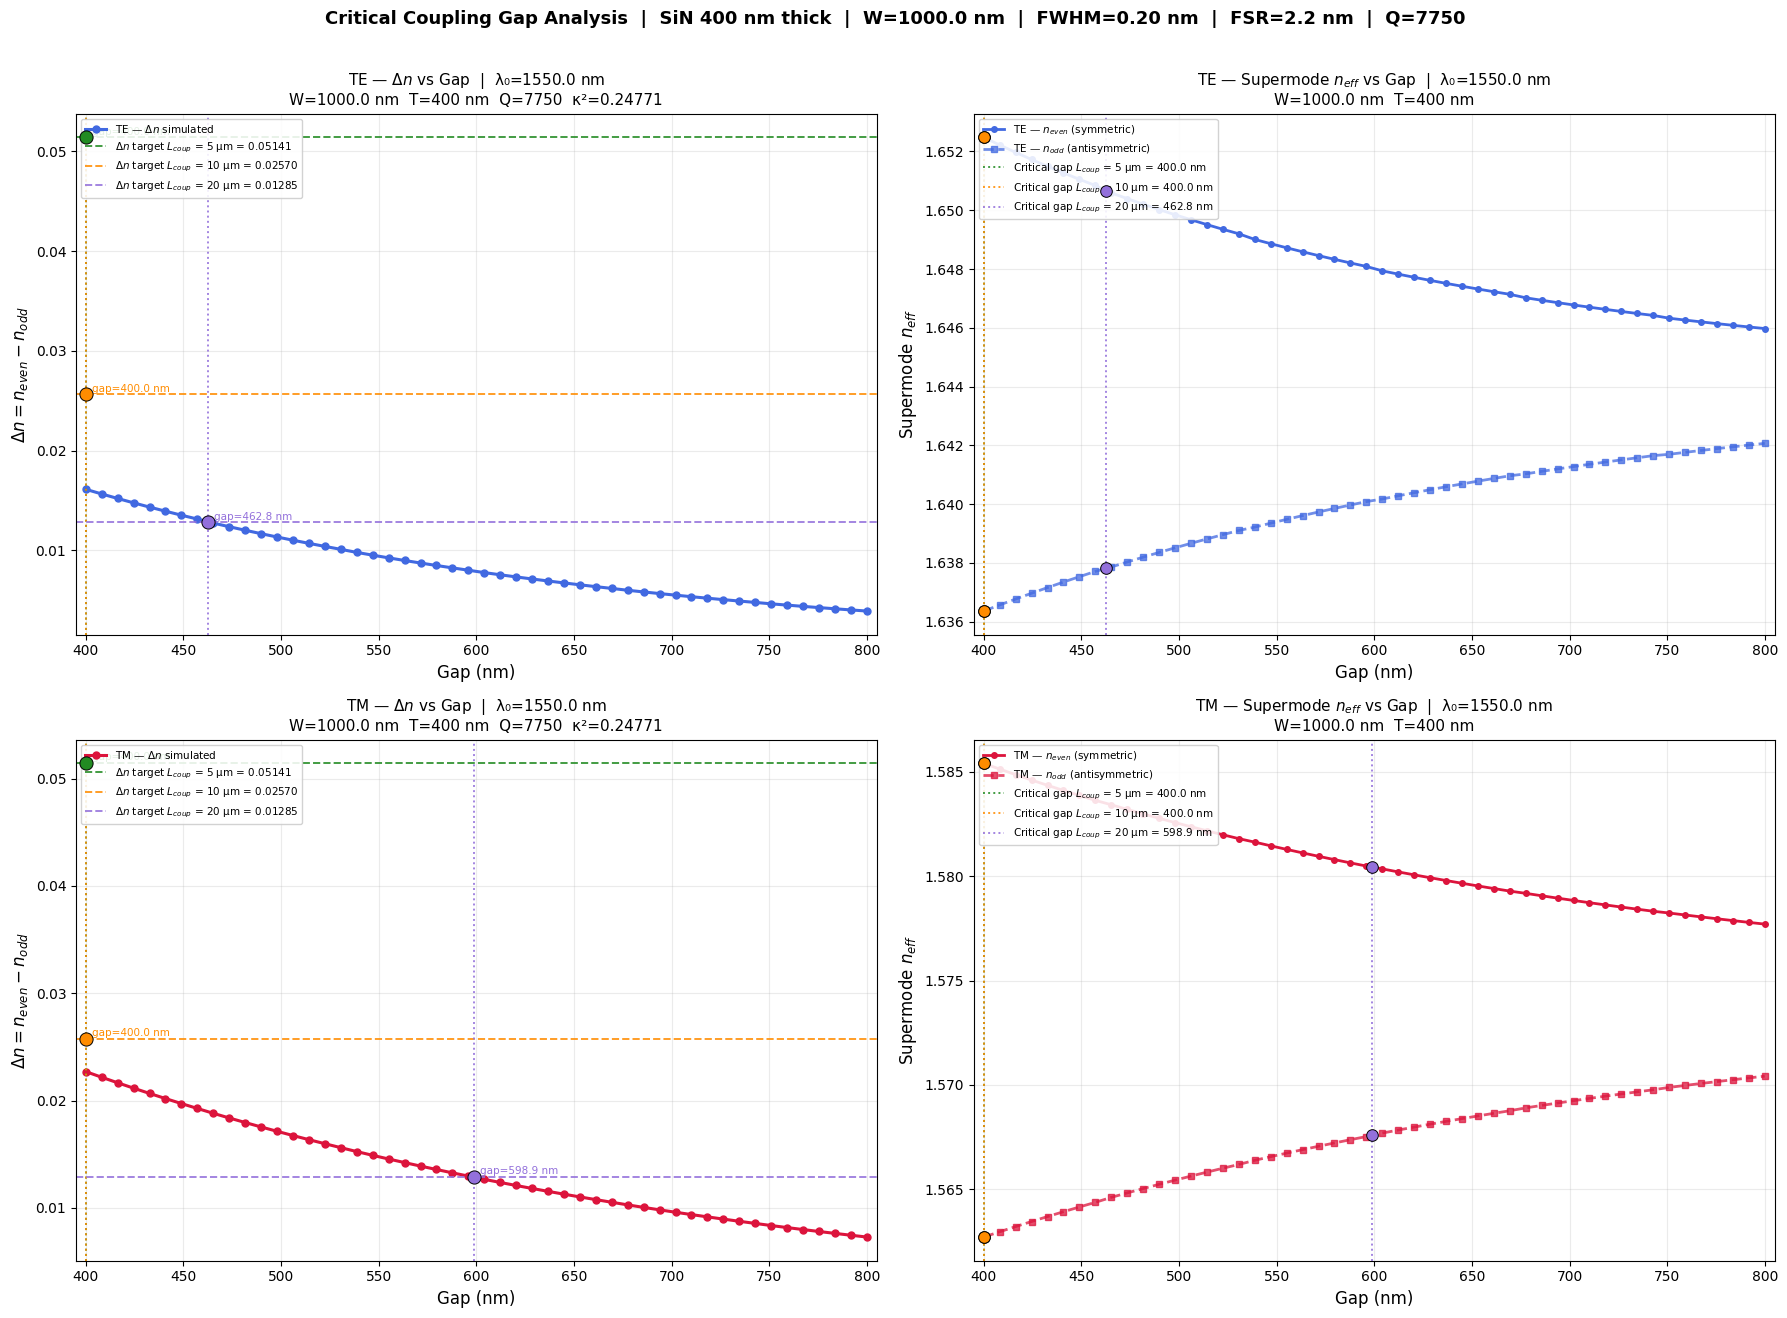

In [28]:
# ── Extract Δn = n_even - n_odd from gap sweep simulation ────────────────────
# For each gap: mode_index=0 → even (symmetric) supermode
#               mode_index=1 → odd  (antisymmetric) supermode
# Δn[pol_idx][gap_idx][freq_idx] = n_even - n_odd


lambda_0_um  = 1.550
lambda_0_idx = np.argmin(np.abs(sweep_wavelength - lambda_0_um))
FWHM_nm      = 0.2
FWHM_um      = FWHM_nm * 1e-3

delta_n_gap  = [[], []]   # [pol_idx][gap_idx] → scalar Δn at λ₀
n_even_gap   = [[], []]   # even supermode neff vs gap
n_odd_gap    = [[], []]   # odd  supermode neff vs gap

for pol_idx in range(2):
    for gap_idx in range(len(sweep_gap)):

        neff_all = (
            sim_data_arr_gap[pol_idx][gap_idx]
            .modes_raw
            .n_complex.abs
            .isel(f=lambda_0_idx)
            .squeeze()
            .values
        )  # shape: (num_modes,) sorted ascending by neff → index 0 = highest = even

        # After ascending sort by tidy3d: index 0 = fundamental (even), index 1 = odd
        n_even = float(neff_all[0])
        n_odd  = float(neff_all[1])

        n_even_gap[pol_idx].append(n_even)
        n_odd_gap [pol_idx].append(n_odd)
        delta_n_gap[pol_idx].append(n_even - n_odd)

# Convert to numpy arrays
for pol_idx in range(2):
    n_even_gap [pol_idx] = np.array(n_even_gap [pol_idx])
    n_odd_gap  [pol_idx] = np.array(n_odd_gap  [pol_idx])
    delta_n_gap[pol_idx] = np.array(delta_n_gap[pol_idx])

# ── For each target Δn (3 coupler lengths) find the gap by interpolation ──────
# results: gap_critical[pol_idx][L_coup_idx] = gap in nm
gap_critical   = [[], []]
Dn_interp_vals = [[], []]

for pol_idx, res in enumerate([res_TE, res_TM]):
    for coup_idx, Dn_target in enumerate(res['Δn values']):
        if np.isnan(Dn_target):
            gap_critical  [pol_idx].append(np.nan)
            Dn_interp_vals[pol_idx].append(np.nan)
            continue

        # Δn decreases monotonically with increasing gap
        # interpolate gap as function of Δn (invert the curve)
        # np.interp requires x to be increasing → flip arrays
        Dn_arr_flip  = delta_n_gap[pol_idx][::-1]
        gap_arr_flip = sweep_gap[::-1]

        if Dn_target < Dn_arr_flip[0] or Dn_target > Dn_arr_flip[-1]:
            # target outside simulated range — extrapolate with a warning
            gap_found = np.interp(Dn_target, Dn_arr_flip, gap_arr_flip)
            print(f"  WARNING [{['TE','TM'][pol_idx]}, L_coup="
                  f"{res['L_coup values (µm)'][coup_idx]:.0f}µm]: "
                  f"Δn={Dn_target:.5f} outside sweep range — extrapolated "
                  f"gap={gap_found*1e3:.1f} nm")
        else:
            gap_found = np.interp(Dn_target, Dn_arr_flip, gap_arr_flip)

        gap_critical  [pol_idx].append(gap_found)
        Dn_interp_vals[pol_idx].append(
            np.interp(gap_found, sweep_gap, delta_n_gap[pol_idx])
        )

# ── Print results table ───────────────────────────────────────────────────────
def print_gap_table(pol_idx, res):
    sep = "─" * 72
    pol = res['pol']
    print(f"\n{sep}")
    print(f"  Critical Coupling Gap — {pol} Polarisation  "
          f"|  λ₀={lambda_0_um*1e3:.1f} nm  |  FWHM={FWHM_nm:.2f} nm")
    print(f"  κ = {res['κ (cross-coup.)']:.5f}   "
          f"κ² = {res['κ² (power coup.)']:.5f}   "
          f"Q = {res['Q']:.0f}   F = {res['Finesse']:.2f}")
    print(sep)
    print(f"  {'L_coup (µm)':<14s}  {'Δn target':<14s}  "
          f"{'Gap (nm)':<12s}  {'Δn @ gap':<14s}  {'Δn error':<12s}")
    print(f"  {'─'*14}  {'─'*14}  {'─'*12}  {'─'*14}  {'─'*12}")
    for i, (L_coup, Dn_tgt, gap_nm, Dn_got) in enumerate(zip(
        res['L_coup values (µm)'],
        res['Δn values'],
        gap_critical[pol_idx],
        Dn_interp_vals[pol_idx]
    )):
        err = abs(Dn_got - Dn_tgt) if not np.isnan(Dn_got) else np.nan
        print(f"  {L_coup:<14.1f}  {Dn_tgt:<14.6f}  "
              f"{gap_nm*1e3:<12.2f}  {Dn_got:<14.6f}  {err:<12.2e}")
    print(sep)

print_gap_table(0, res_TE)
print_gap_table(1, res_TM)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

colors_coup  = ['forestgreen', 'darkorange', 'mediumpurple']
colors_pol   = ['royalblue', 'crimson']
L_coup_labels= [f"$L_{{coup}}$ = {l:.0f} µm" for l in res_TE['L_coup values (µm)']]

for pol_idx, (res, color_pol) in enumerate(zip([res_TE, res_TM], colors_pol)):

    # ── Top row: Δn vs gap ────────────────────────────────────────────────────
    ax_dn = axes[pol_idx, 0]

    ax_dn.plot(
        sweep_gap * 1e3,
        delta_n_gap[pol_idx],
        color=color_pol, linewidth=2.2,
        marker='o', markersize=5,
        label=f"{res['pol']} — $\\Delta n$ simulated"
    )

    # target Δn lines and gap markers
    for coup_idx, (Dn_tgt, gap_nm, c, lbl) in enumerate(zip(
        res['Δn values'],
        gap_critical[pol_idx],
        colors_coup,
        L_coup_labels
    )):
        if np.isnan(Dn_tgt):
            continue

        # horizontal target line
        ax_dn.axhline(
            Dn_tgt, color=c, linestyle='--', linewidth=1.4, alpha=0.85,
            label=f"$\\Delta n$ target {lbl} = {Dn_tgt:.5f}"
        )
        # vertical gap line
        ax_dn.axvline(
            gap_nm * 1e3, color=c, linestyle=':', linewidth=1.4, alpha=0.85
        )
        # intersection marker
        ax_dn.scatter(
            gap_nm * 1e3, Dn_tgt,
            color=c, s=90, zorder=6, edgecolors='black', linewidths=0.7
        )
        # text label
        ax_dn.text(
            gap_nm * 1e3 + 3, Dn_tgt + delta_n_gap[pol_idx].max() * 0.012,
            f"gap={gap_nm*1e3:.1f} nm",
            fontsize=7.5, color=c
        )

    ax_dn.set_xlabel("Gap (nm)",                         fontsize=12)
    ax_dn.set_ylabel("$\\Delta n = n_{even} - n_{odd}$", fontsize=12)
    ax_dn.set_title(
        f"{res['pol']} — $\\Delta n$ vs Gap  |  λ₀={lambda_0_um*1e3:.1f} nm\n"
        f"W={safe_width_nm:.1f} nm  T={core_thickness*1e3:.0f} nm  "
        f"Q={res['Q']:.0f}  κ²={res['κ² (power coup.)']:.5f}",
        fontsize=11
    )
    ax_dn.legend(fontsize=7.5, loc='upper left', framealpha=0.88)
    ax_dn.set_xlim(sweep_gap[0]*1e3 - 5, sweep_gap[-1]*1e3 + 5)
    ax_dn.grid(True, alpha=0.25)

    # ── Bottom row: n_even and n_odd vs gap ───────────────────────────────────
    ax_nm = axes[pol_idx, 1]

    ax_nm.plot(
        sweep_gap * 1e3, n_even_gap[pol_idx],
        color=color_pol, linewidth=2.0, linestyle='-',
        marker='o', markersize=4,
        label=f"{res['pol']} — $n_{{even}}$ (symmetric)"
    )
    ax_nm.plot(
        sweep_gap * 1e3, n_odd_gap[pol_idx],
        color=color_pol, linewidth=2.0, linestyle='--',
        marker='s', markersize=4, alpha=0.75,
        label=f"{res['pol']} — $n_{{odd}}$ (antisymmetric)"
    )

    # mark critical gap positions on supermode curves
    for coup_idx, (gap_nm, c, lbl) in enumerate(zip(
        gap_critical[pol_idx], colors_coup, L_coup_labels
    )):
        if np.isnan(gap_nm):
            continue
        n_even_at_gap = np.interp(gap_nm, sweep_gap, n_even_gap[pol_idx])
        n_odd_at_gap  = np.interp(gap_nm, sweep_gap, n_odd_gap [pol_idx])

        ax_nm.axvline(
            gap_nm * 1e3, color=c, linestyle=':', linewidth=1.4, alpha=0.85,
            label=f"Critical gap {lbl} = {gap_nm*1e3:.1f} nm"
        )
        ax_nm.scatter(
            [gap_nm*1e3, gap_nm*1e3],
            [n_even_at_gap, n_odd_at_gap],
            color=c, s=70, zorder=6, edgecolors='black', linewidths=0.7
        )

    ax_nm.set_xlabel("Gap (nm)",                fontsize=12)
    ax_nm.set_ylabel("Supermode $n_{eff}$",     fontsize=12)
    ax_nm.set_title(
        f"{res['pol']} — Supermode $n_{{eff}}$ vs Gap  |  λ₀={lambda_0_um*1e3:.1f} nm\n"
        f"W={safe_width_nm:.1f} nm  T={core_thickness*1e3:.0f} nm",
        fontsize=11
    )
    ax_nm.legend(fontsize=7.5, loc='upper left', framealpha=0.88)
    ax_nm.set_xlim(sweep_gap[0]*1e3 - 5, sweep_gap[-1]*1e3 + 5)
    ax_nm.grid(True, alpha=0.25)

plt.suptitle(
    f"Critical Coupling Gap Analysis  |  SiN {core_thickness*1e3:.0f} nm thick  "
    f"|  W={safe_width_nm:.1f} nm  |  FWHM={FWHM_nm:.2f} nm  "
    f"|  FSR={FSR_target_nm:.1f} nm  |  Q={res_TE['Q']:.0f}",
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    str(data_dir / f"{version_name_gap}_critical_gap_analysis.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()

21:55:04 Hora est. Pacífico, Sudamérica WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

                                        WARNING: Structure at 'structures[0]'   
                                        has bounds that extend exactly to       
                                        simulation edges. This can cause        
                                        unexpected behavior. If intending to    
                                        extend the structure to infinity along  
                                        one dimension, use td.inf as a size     
                                        variable instead to make this explicit. 

                                        WARNING: Structure at 'structures[0]'   
                                        has bounds that extend exactly to       
                                        simulation edges. This can cause        
                                        unexpected behavior. If intending to    
                                        extend the structure to infinity along  
                                        one dimension, use td.inf as a size     
                                        variable instead to make this explicit. 

                                        WARNING: The original simulation is     
                                        symmetric along z direction. The mode   
                                        simulation region does cross the        
                                        symmetry plane but is not symmetric with
                                        respect to it. To preserve correct      
                                        symmetry, the requested simulation      
                                        region will be expanded by the solver.  

                                        WARNING: Structure at 'structures[0]'   
                                        has bounds that extend exactly to       
                                        simulation edges. This can cause        
                                        unexpected behavior. If intending to    
                                        extend the structure to infinity along  
                                        one dimension, use td.inf as a size     
                                        variable instead to make this explicit. 

...

                                        WARNING: The original simulation is     
                                        symmetric along z direction. The mode   
                                        simulation region does cross the        
                                        symmetry plane but is not symmetric with
                                        respect to it. To preserve correct      
                                        symmetry, the requested simulation      
                                        region will be expanded by the solver.  

21:55:05 Hora est. Pacífico, Sudamérica WARNING: Structure at 'structures[0]'   
                                        has bounds that extend exactly to       
                                        simulation edges. This can cause        
                                        unexpected behavior. If intending to    
                                        extend the structure to infinity along  
                                        one dimension, use td.inf as a size     
                                        variable instead to make this explicit. 

                                        WARNING: Structure at 'structures[0]'   
                                        has bounds that extend exactly to       
                                        simulation edges. This can cause        
                                        unexpected behavior. If intending to    
                                        extend the structure to infinity along  
                                        one dimension, use td.inf as a size     
                                        variable instead to make this explicit. 

                                        WARNING: The original simulation is     
                                        symmetric along z direction. The mode   
                                        simulation region does cross the        
                                        symmetry plane but is not symmetric with
                                        respect to it. To preserve correct      
                                        symmetry, the requested simulation      
                                        region will be expanded by the solver.  

  Loaded [TM]: data_STRp_SiN_mode_analysis/SiN_sim_400_aqueous_clad_V1/polTM/aqueous_clad_1000nm.hdf5

Estimated Maximum Cost: 0


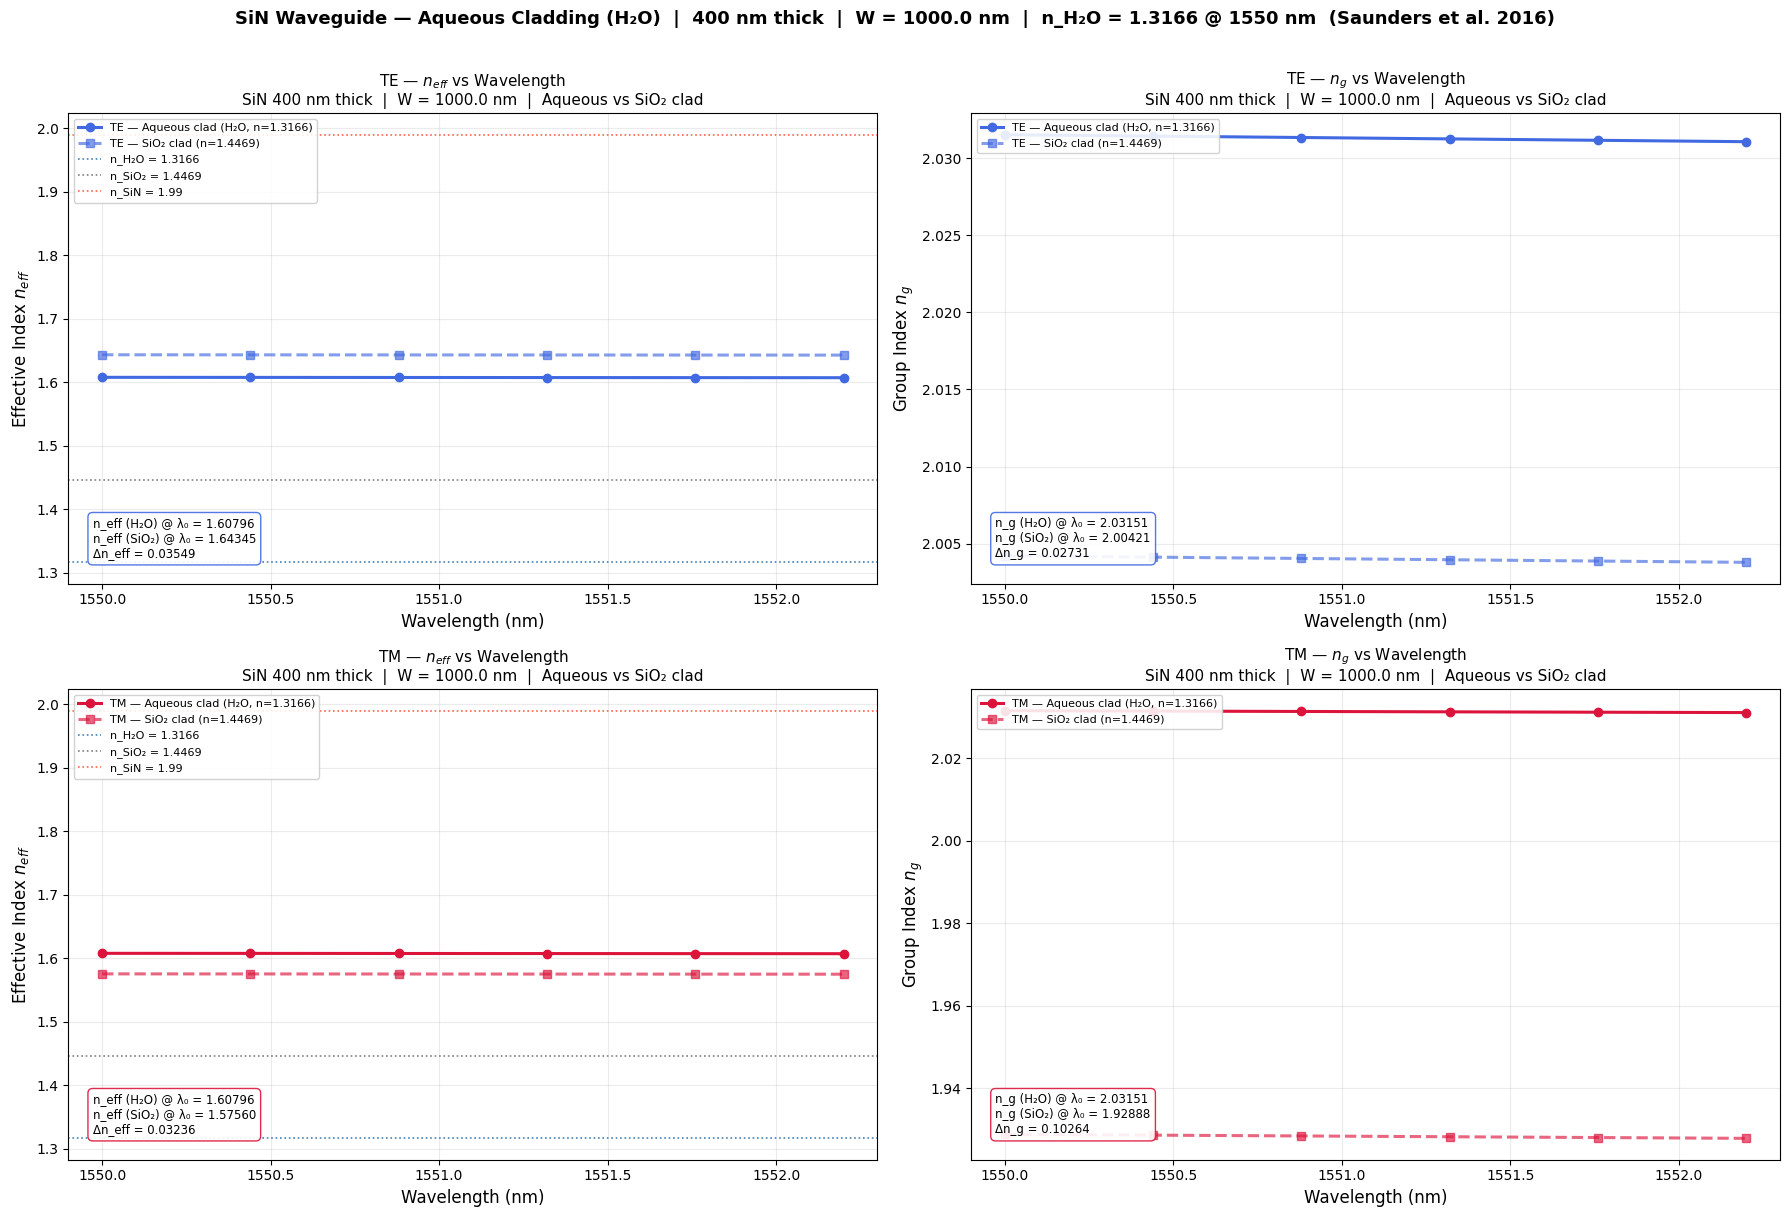

In [29]:
# ── Aqueous cladding simulation — SiN strip in water environment ──────────────
# Structure: SiO2 substrate (lower) | SiN waveguide | H2O cladding (top+sides)
#
# n_H2O @ 1550 nm = 1.3166  (Saunders et al., Appl. Opt. 55, 947, 2016)
# Confirmed by Daimon & Masumura (2007) Sellmeier formula at 1550 nm.
# Note: this is lower than the visible value (~1.333) due to normal dispersion.
#
# Reuses from existing code:
#   sweep_wavelength, sweep_freq, core_thickness, fixed_width,
#   safe_width_nm, safe_width_idx, n_SiN, n_SiO2,
#   data_dir, version_name

n_water_1550       = 1.3166          # pure water @ 1550 nm, 20°C (Saunders 2016)
version_name_water = "SiN_sim_400_aqueous_clad_V1"

def build_aqueous_simulation(
    core_width      = fixed_width,
    core_thickness  = 0.400,
    wavelength      = sweep_wavelength,
    version_name    = "SiN_aqueous_clad"
):
    base_path = f"data_STRp_SiN_mode_analysis/{version_name}"
    os.makedirs(base_path, exist_ok=True)

    freqs = td.C_0 / wavelength

    # ── Materials ─────────────────────────────────────────────────────────────
    core_medium = td.Medium(
        name         = 'core_SiN_medium',
        permittivity = 1.99**2,
    )

    # Lower cladding: SiO2 substrate — same as original simulations
    substrate_medium = td.Medium(
        name         = 'substrate_SiO2_medium',
        permittivity = 1.4469404291704726**2,
    )

    # Upper + lateral cladding: pure water @ 1550 nm
    water_medium = td.Medium(
        name         = 'water_H2O_medium',
        permittivity = n_water_1550**2,      # 1.3166² = 1.73344
    )

    # ── Geometry ──────────────────────────────────────────────────────────────
    # SiN waveguide strip: same fixed_width and core_thickness
    waveguide = td.Structure(
        geometry = td.Box(
            center = [0, 0, core_thickness / 2],   # sits on top of substrate
            size   = [td.inf, core_width, core_thickness]
        ),
        name   = 'waveguide',
        medium = core_medium
    )

    # SiO2 substrate slab: occupies lower half of simulation domain
    # Domain z is 7µm → substrate fills from -3.5 to 0 (below waveguide base)
    substrate = td.Structure(
        geometry = td.Box(
            center = [0, 0, -3.5 / 2],            # centered in lower half
            size   = [td.inf, td.inf, 3.5]
        ),
        name   = 'substrate',
        medium = substrate_medium
    )

    # ── Simulation objects and data containers ────────────────────────────────
    sim_data_arr = [None, None]   # [pol_idx] → single ModeSimulationData
    sim_arr      = [None, None]   # [pol_idx] → single ModeSimulation

    estimate = 0

    for (pol_idx, pol_value) in enumerate(['TE', 'TM']):

        pol_folder = f"{base_path}/pol{pol_value}"
        os.makedirs(pol_folder, exist_ok=True)

        filename = f"{pol_folder}/aqueous_clad_{int(core_width*1000)}nm.hdf5"

        # Background medium = water (replaces the uniform SiO2 cladding)
        # Substrate is an explicit structure below the waveguide
        sim_arr[pol_idx] = td.ModeSimulation(
            freqs     = freqs,
            mode_spec = td.ModeSpec(
                target_neff      = 1.99,
                num_modes        = 4,
                sort_spec        = {
                    'filter_reference' : 0,
                    'filter_order'     : 'over',
                    'sort_order'       : 'ascending',
                    'track_freq'       : 'central'
                },
                group_index_step = True,
            ),
            size      = [7, 7, 7],
            grid_spec = td.GridSpec(
                grid_x     = td.AutoGrid(min_steps_per_wvl=15),
                grid_y     = td.AutoGrid(min_steps_per_wvl=15),
                grid_z     = td.AutoGrid(min_steps_per_wvl=15),
                wavelength = 1.550,
            ),
            version    = '2.10.1',
            medium     = water_medium,          # background = water everywhere
            sources    = [],
            monitors   = [],
            structures = [substrate, waveguide], # substrate inserted explicitly
            symmetry   = [0, 0,  1] if pol_value == 'TE' else [0, 0, -1],
            plane      = td.Box(center=[0, 0, core_thickness / 2],
                                size=[0, 7, 7])
        )

        if os.path.exists(filename):
            sim_data_arr[pol_idx] = td.ModeSimulationData.from_file(Path(filename))
            print(f"  Loaded [{pol_value}]: {filename}")

        else:
            task_name = f"{version_name}_P{pol_value}_W{int(core_width*1000)}_AqClad"
            job       = web.Job(
                simulation = sim_arr[pol_idx],
                task_name  = task_name
            )
            print(f"  Running [{pol_value}]: {task_name}")
            sim_data_arr[pol_idx] = job.run()
            sim_data_arr[pol_idx].to_file(filename)

            Job      = web.Job(
                simulation = sim_arr[pol_idx],
                task_name  = "cost_estimate"
            )
            estimate += Job.estimate_cost()

    print(f"\nEstimated Maximum Cost: {estimate}")
    return sim_data_arr, sim_arr


# ── Run ───────────────────────────────────────────────────────────────────────
sim_data_water, sim_arr_water = build_aqueous_simulation(
    core_width     = fixed_width,
    core_thickness = core_thickness,
    wavelength     = sweep_wavelength,
    version_name   = version_name_water
)
# ── Extract n_eff and n_group vs wavelength for both polarizations ─────────────
# Compare directly against the original SiO2-clad results at safe_width_idx

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
colors_pol = ['royalblue', 'crimson']


# After the loop in Cell 10:
neff_aq_TE_1550 = float(
    sim_data_water[0].modes_raw.n_complex.abs
    .isel(mode_index=0).squeeze().values[lambda_0_idx]
)
neff_aq_TM_1550 = float(
    sim_data_water[1].modes_raw.n_complex.abs
    .isel(mode_index=0).squeeze().values[lambda_0_idx]
)


for pol_idx, pol_value in enumerate(['TE', 'TM']):

    # ── Aqueous cladding results ───────────────────────────────────────────────
    neff_water = (
        sim_data_water[pol_idx]
        .modes_raw.n_complex.abs
        .isel(mode_index=0)
        .squeeze()
        .values
    )   # shape: (len(sweep_wavelength),)

    ng_water = (
        sim_data_water[pol_idx]
        .modes_raw.n_group
        .isel(mode_index=0)
        .squeeze()
        .values
    )

    # ── Original SiO2-clad results at safe_width_idx for direct comparison ────
    neff_sio2 = (
        sim_data_arr_modes[pol_idx][safe_width_idx]
        .modes_raw.n_complex.abs
        .isel(mode_index=0)
        .squeeze()
        .values
    )

    ng_sio2 = (
        sim_data_arr_modes[pol_idx][safe_width_idx]
        .modes_raw.n_group
        .isel(mode_index=0)
        .squeeze()
        .values
    )

    wl_nm = sweep_wavelength * 1e3

    # ── Left column: n_eff vs wavelength ──────────────────────────────────────
    ax_neff = axes[pol_idx, 0]

    ax_neff.plot(
        wl_nm, neff_water,
        color=colors_pol[pol_idx], linewidth=2.2,
        marker='o', markersize=6,
        label=f"{pol_value} — Aqueous clad (H₂O, n={n_water_1550})"
    )
    ax_neff.plot(
        wl_nm, neff_sio2,
        color=colors_pol[pol_idx], linewidth=2.2,
        linestyle='--', marker='s', markersize=6, alpha=0.65,
        label=f"{pol_value} — SiO₂ clad (n=1.4469)"
    )

    # reference index lines
    ax_neff.axhline(
        n_water_1550, color='steelblue', linestyle=':', linewidth=1.2,
        label=f'n_H₂O = {n_water_1550}'
    )
    ax_neff.axhline(
        1.4469404291704726, color='gray', linestyle=':', linewidth=1.2,
        label='n_SiO₂ = 1.4469'
    )
    ax_neff.axhline(
        1.99, color='tomato', linestyle=':', linewidth=1.2,
        label='n_SiN = 1.99'
    )

    stats_text = (
        f"n_eff (H₂O) @ λ₀ = {neff_water[lambda_0_idx]:.5f}\n"
        f"n_eff (SiO₂) @ λ₀ = {neff_sio2[lambda_0_idx]:.5f}\n"
        f"Δn_eff = {abs(neff_water[lambda_0_idx]-neff_sio2[lambda_0_idx]):.5f}"
    )
    ax_neff.text(
        0.03, 0.05, stats_text,
        transform=ax_neff.transAxes, fontsize=8.5,
        va='bottom', ha='left',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=colors_pol[pol_idx], alpha=0.9)
    )

    ax_neff.set_xlabel("Wavelength (nm)",             fontsize=12)
    ax_neff.set_ylabel("Effective Index $n_{eff}$",   fontsize=12)
    ax_neff.set_title(
        f"{pol_value} — $n_{{eff}}$ vs Wavelength\n"
        f"SiN {core_thickness*1e3:.0f} nm thick  |  "
        f"W = {safe_width_nm:.1f} nm  |  Aqueous vs SiO₂ clad",
        fontsize=11
    )
    ax_neff.set_xlim(wl_nm[0] - 0.1, wl_nm[-1] + 0.1)
    ax_neff.legend(fontsize=8, loc='upper left', framealpha=0.88)
    ax_neff.grid(True, alpha=0.25)

    # ── Right column: n_group vs wavelength ───────────────────────────────────
    ax_ng = axes[pol_idx, 1]

    ax_ng.plot(
        wl_nm, ng_water,
        color=colors_pol[pol_idx], linewidth=2.2,
        marker='o', markersize=6,
        label=f"{pol_value} — Aqueous clad (H₂O, n={n_water_1550})"
    )
    ax_ng.plot(
        wl_nm, ng_sio2,
        color=colors_pol[pol_idx], linewidth=2.2,
        linestyle='--', marker='s', markersize=6, alpha=0.65,
        label=f"{pol_value} — SiO₂ clad (n=1.4469)"
    )

    stats_text_ng = (
        f"n_g (H₂O) @ λ₀ = {ng_water[lambda_0_idx]:.5f}\n"
        f"n_g (SiO₂) @ λ₀ = {ng_sio2[lambda_0_idx]:.5f}\n"
        f"Δn_g = {abs(ng_water[lambda_0_idx]-ng_sio2[lambda_0_idx]):.5f}"
    )
    ax_ng.text(
        0.03, 0.05, stats_text_ng,
        transform=ax_ng.transAxes, fontsize=8.5,
        va='bottom', ha='left',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=colors_pol[pol_idx], alpha=0.9)
    )

    ax_ng.set_xlabel("Wavelength (nm)",         fontsize=12)
    ax_ng.set_ylabel("Group Index $n_g$",        fontsize=12)
    ax_ng.set_title(
        f"{pol_value} — $n_g$ vs Wavelength\n"
        f"SiN {core_thickness*1e3:.0f} nm thick  |  "
        f"W = {safe_width_nm:.1f} nm  |  Aqueous vs SiO₂ clad",
        fontsize=11
    )
    ax_ng.set_xlim(wl_nm[0] - 0.1, wl_nm[-1] + 0.1)
    ax_ng.legend(fontsize=8, loc='upper left', framealpha=0.88)
    ax_ng.grid(True, alpha=0.25)

plt.suptitle(
    f"SiN Waveguide — Aqueous Cladding (H₂O)  |  "
    f"{core_thickness*1e3:.0f} nm thick  |  W = {safe_width_nm:.1f} nm  |  "
    f"n_H₂O = {n_water_1550} @ 1550 nm  (Saunders et al. 2016)",
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    str(data_dir / f"{version_name_water}_neff_ngroup.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()

In [30]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 1 — Aqueous double-strip gap sweep simulation
# Reuses: fixed_width, core_thickness, sweep_wavelength, sweep_freq,
#         n_water_1550, data_dir, version_name_water, sweep_gap (redefined below)
# ═══════════════════════════════════════════════════════════════════════════════

sweep_gap_aq      = np.linspace(0.400, 0.700, 20)   # 400–700 nm, 20 points
version_name_aq_gap = "SiN_sim_400_aqueous_gap_sweep_V1"

def build_aqueous_gap_sweep(
    core_width      = fixed_width,
    core_thickness  = 0.400,
    sweep_gap       = sweep_gap_aq,
    wavelength      = sweep_wavelength,
    version_name    = "SiN_aqueous_gap_sweep"
):
    base_path = f"data_STRp_SiN_mode_analysis/{version_name}"
    os.makedirs(base_path, exist_ok=True)

    freqs = td.C_0 / wavelength

    core_medium = td.Medium(
        name         = 'core_SiN_medium',
        permittivity = 1.99**2,
    )
    substrate_medium = td.Medium(
        name         = 'substrate_SiO2_medium',
        permittivity = 1.4469404291704726**2,
    )
    water_medium = td.Medium(
        name         = 'water_H2O_medium',
        permittivity = n_water_1550**2,
    )

    sim_data_arr = [[], []]
    sim_arr      = [[], []]
    estimate     = 0

    for (pol_idx, pol_value) in enumerate(['TE', 'TM']):

        pol_folder = f"{base_path}/pol{pol_value}"
        os.makedirs(pol_folder, exist_ok=True)

        for (gap_idx, gap_value) in enumerate(sweep_gap):

            filename = f"{pol_folder}/gap_{int(gap_value*1000)}.hdf5"

            center_offset = core_width / 2 + gap_value / 2

            waveguide_1 = td.Structure(
                geometry = td.Box(
                    center = [0,  center_offset, core_thickness / 2],
                    size   = [td.inf, core_width, core_thickness]
                ),
                name   = 'waveguide_1',
                medium = core_medium
            )

            waveguide_2 = td.Structure(
                geometry = td.Box(
                    center = [0, -center_offset, core_thickness / 2],
                    size   = [td.inf, core_width, core_thickness]
                ),
                name   = 'waveguide_2',
                medium = core_medium
            )

            # SiO2 substrate: explicit slab below waveguides
            substrate = td.Structure(
                geometry = td.Box(
                    center = [0, 0, -3.5 / 2],
                    size   = [td.inf, td.inf, 3.5]
                ),
                name   = 'substrate',
                medium = substrate_medium
            )

            # domain y: contains both waveguides + water margins
            domain_y = 2 * core_width + gap_value + 4.0

            sim_arr[pol_idx].append(td.ModeSimulation(
                freqs     = freqs,
                mode_spec = td.ModeSpec(
                    target_neff      = 1.99,
                    num_modes        = 4,
                    sort_spec        = {
                        'filter_reference' : 0,
                        'filter_order'     : 'over',
                        'sort_order'       : 'ascending',
                        'track_freq'       : 'central'
                    },
                    group_index_step = True,
                ),
                size      = [7, domain_y, 7],
                grid_spec = td.GridSpec(
                    grid_x     = td.AutoGrid(min_steps_per_wvl=15),
                    grid_y     = td.AutoGrid(min_steps_per_wvl=15),
                    grid_z     = td.AutoGrid(min_steps_per_wvl=15),
                    wavelength = 1.550,
                ),
                version    = '2.10.1',
                medium     = water_medium,
                sources    = [],
                monitors   = [],
                structures = [substrate, waveguide_1, waveguide_2],
                # No y-symmetry: need both even and odd supermodes
                # z-symmetry separates TE/TM
                symmetry   = [0, 0,  1] if pol_value == 'TE' else [0, 0, -1],
                plane      = td.Box(
                    center = [0, 0, core_thickness / 2],
                    size   = [0, domain_y, 7]
                )
            ))

            if os.path.exists(filename):
                sim_data_arr[pol_idx].append(
                    td.ModeSimulationData.from_file(Path(filename))
                )
                print(f"  Loaded [{pol_value}] gap={gap_value*1e3:.0f} nm")
            else:
                task_name = f"{version_name}_P{pol_value}_G{int(gap_value*1000)}"
                job = web.Job(
                    simulation = sim_arr[pol_idx][gap_idx],
                    task_name  = task_name
                )
                print(f"  Running [{pol_value}] gap={gap_value*1e3:.0f} nm")
                sim_data_arr[pol_idx].append(job.run())
                sim_data_arr[pol_idx][gap_idx].to_file(filename)

                Job = web.Job(
                    simulation = sim_arr[pol_idx][gap_idx],
                    task_name  = "cost_estimate"
                )
                estimate += Job.estimate_cost()

    print(f"\nEstimated Maximum Cost: {estimate}")
    return sim_data_arr, sim_arr


# ── Run ───────────────────────────────────────────────────────────────────────
sim_data_arr_aq_gap, sim_arr_aq_gap = build_aqueous_gap_sweep(
    core_width     = fixed_width,
    core_thickness = core_thickness,
    sweep_gap      = sweep_gap_aq,
    wavelength     = sweep_wavelength,
    version_name   = version_name_aq_gap
)

21:55:06 Hora est. Pacífico, Sudamérica WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

                                        WARNING: Structure at 'structures[0]'   
                                        has bounds that extend exactly to       
                                        simulation edges. This can cause        
                                        unexpected behavior. If intending to    
                                        extend the structure to infinity along  
                                        one dimension, use td.inf as a size     
                                        variable instead to make this explicit. 

                                        WARNING: Structure at 'structures[0]'   
                                        has bounds that extend exactly to       
                                        simulation edges. This can cause        
                                        unexpected behavior. If intending to    
                                        extend the structure to infinity along  
                                        one dimension, use td.inf as a size     
                                        variable instead to make this explicit. 

                                        WARNING: The original simulation is     
                                        symmetric along z direction. The mode   
                                        simulation region does cross the        
                                        symmetry plane but is not symmetric with
                                        respect to it. To preserve correct      
                                        symmetry, the requested simulation      
                                        region will be expanded by the solver.  

21:55:07 Hora est. Pacífico, Sudamérica WARNING: Structure at 'structures[0]'   
                                        has bounds that extend exactly to       
                                        simulation edges. This can cause        
                                        unexpected behavior. If intending to    
                                        extend the structure to infinity along  
                                        one dimension, use td.inf as a size     
                                        variable instead to make this explicit. 

...

                                        WARNING: The original simulation is     
                                        symmetric along z direction. The mode   
                                        simulation region does cross the        
                                        symmetry plane but is not symmetric with
                                        respect to it. To preserve correct      
                                        symmetry, the requested simulation      
                                        region will be expanded by the solver.  

                                        WARNING: Structure at 'structures[0]'   
                                        has bounds that extend exactly to       
                                        simulation edges. This can cause        
                                        unexpected behavior. If intending to    
                                        extend the structure to infinity along  
                                        one dimension, use td.inf as a size     
                                        variable instead to make this explicit. 

                                        WARNING: Structure at 'structures[0]'   
                                        has bounds that extend exactly to       
                                        simulation edges. This can cause        
                                        unexpected behavior. If intending to    
                                        extend the structure to infinity along  
                                        one dimension, use td.inf as a size     
                                        variable instead to make this explicit. 

                                        WARNING: The original simulation is     
                                        symmetric along z direction. The mode   
                                        simulation region does cross the        
                                        symmetry plane but is not symmetric with
                                        respect to it. To preserve correct      
                                        symmetry, the requested simulation      
                                        region will be expanded by the solver.  

  Loaded [TM] gap=700 nm

Estimated Maximum Cost: 0



──────────────────────────────────────────────────────────────────
  TE (aqueous)  |  λ₀=1550.0 nm  |  FWHM=0.20 nm  |  FSR target=2.2 nm
──────────────────────────────────────────────────────────────────
  n_group (aqueous)                       2.031514
  Ring radius R (phase-matched)           85.6015 µm
  Azimuthal mode number m                 347
  Actual FSR @ phase match                2.1988 nm
  Round-trip length L = 2πR               537.8500 µm
──────────────────────────────────────────────────────────────────
  Q factor                                7750.0
  Finesse F                               11.00
  a  (RT field transmission)              0.867345
  t  (self-coupling, t = a)               0.867345
  κ  (cross-coupling field)               0.497708
  κ² (power coupling ratio)               0.247713
  RT power loss (dB)                      1.2362 dB
  Propagation loss α                      22.9835 dB/cm
──────────────────────────────────────────────────────────────

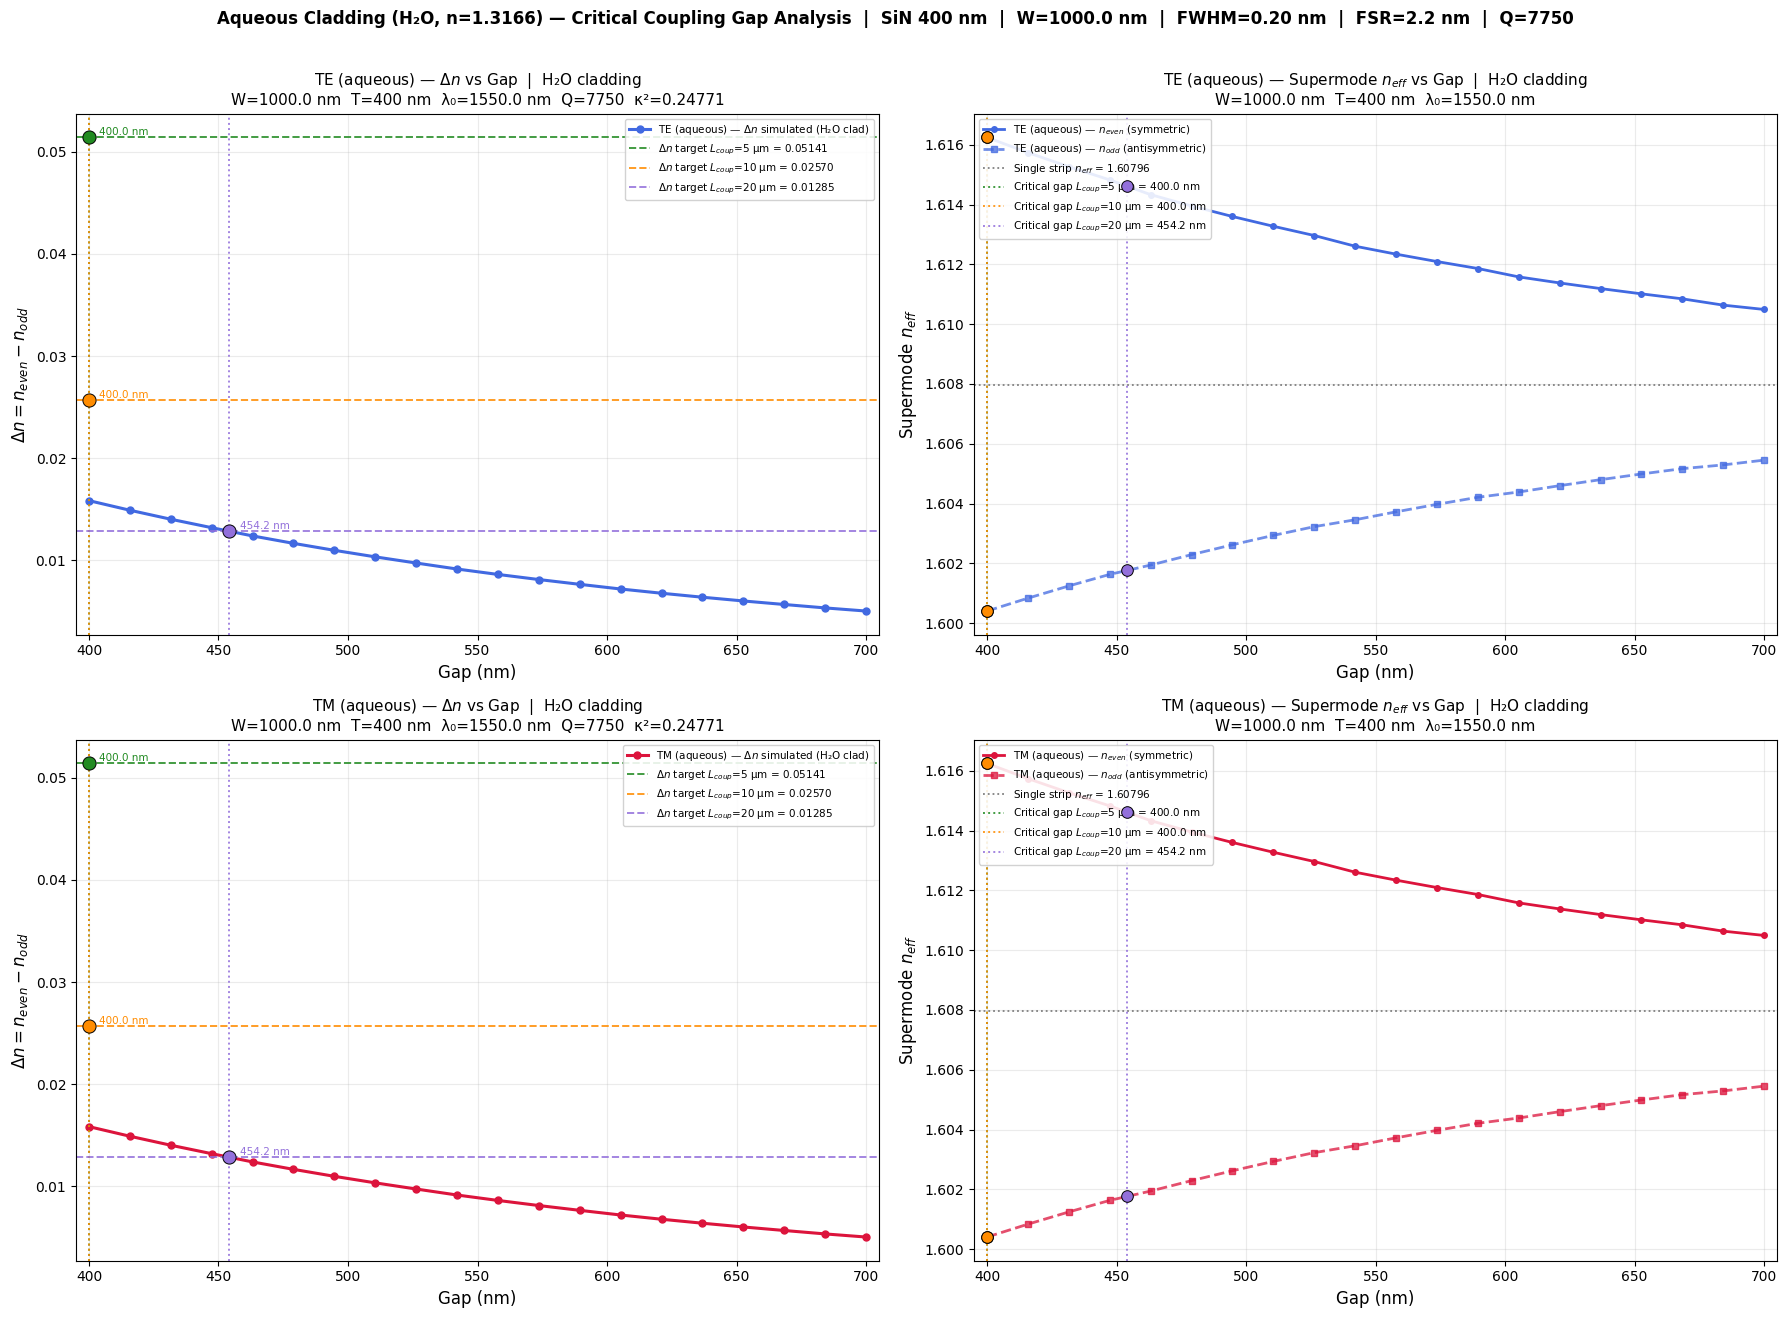

In [31]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 2 — Analysis: ring design + critical coupling + gap finding
# Reuses: sim_data_water, lambda_0_um, FWHM_um, FSR_target_nm,
#         lambda_0_idx, safe_width_nm, core_thickness, compute_ring_radius,
#         critical_coupling_analysis, n_water_1550
# ═══════════════════════════════════════════════════════════════════════════════

# ── 1. n_group from aqueous single-strip simulation at λ₀ ────────────────────
n_g_TE_aq = float(
    sim_data_water[0]
    .modes_raw.n_group
    .isel(mode_index=0).squeeze().values[lambda_0_idx]
)
n_g_TM_aq = float(
    sim_data_water[1]
    .modes_raw.n_group
    .isel(mode_index=0).squeeze().values[lambda_0_idx]
)

# ── 2. Phase-matched ring radius at λ₀ with aqueous n_group ──────────────────
R_ring_TE_aq_um, m_TE_aq, FSR_TE_aq_actual = compute_ring_radius(
    lambda_0_um, n_g_TE_aq, FSR_target_nm * 1e-3
)
R_ring_TM_aq_um, m_TM_aq, FSR_TM_aq_actual = compute_ring_radius(
    lambda_0_um, n_g_TM_aq, FSR_target_nm * 1e-3
)

L_ring_TE_aq = 2 * np.pi * R_ring_TE_aq_um
L_ring_TM_aq = 2 * np.pi * R_ring_TM_aq_um

# ── 3. Critical coupling coefficients with aqueous cladding ──────────────────
res_TE_aq = critical_coupling_analysis(
    n_g_TE_aq, lambda_0_um, FWHM_um, L_ring_TE_aq, FSR_target_nm, 'TE (aqueous)'
)
res_TM_aq = critical_coupling_analysis(
    n_g_TM_aq, lambda_0_um, FWHM_um, L_ring_TM_aq, FSR_target_nm, 'TM (aqueous)'
)

# ── Print ring + coupling summary ─────────────────────────────────────────────
for res, R_ring, m_val, FSR_act in zip(
    [res_TE_aq, res_TM_aq],
    [R_ring_TE_aq_um, R_ring_TM_aq_um],
    [m_TE_aq, m_TM_aq],
    [FSR_TE_aq_actual, FSR_TM_aq_actual]
):
    sep = "─" * 66
    print(f"\n{sep}")
    print(f"  {res['pol']}  |  λ₀={lambda_0_um*1e3:.1f} nm  "
          f"|  FWHM={FWHM_nm:.2f} nm  |  FSR target={FSR_target_nm:.1f} nm")
    print(sep)
    print(f"  {'n_group (aqueous)':<38s}  {res['n_g']:.6f}")
    print(f"  {'Ring radius R (phase-matched)':<38s}  {R_ring:.4f} µm")
    print(f"  {'Azimuthal mode number m':<38s}  {m_val}")
    print(f"  {'Actual FSR @ phase match':<38s}  {FSR_act:.4f} nm")
    print(f"  {'Round-trip length L = 2πR':<38s}  {2*np.pi*R_ring:.4f} µm")
    print(sep)
    print(f"  {'Q factor':<38s}  {res['Q']:.1f}")
    print(f"  {'Finesse F':<38s}  {res['Finesse']:.2f}")
    print(f"  {'a  (RT field transmission)':<38s}  {res['a (field trans.)']:.6f}")
    print(f"  {'t  (self-coupling, t = a)':<38s}  {res['t (self-coup.)']:.6f}")
    print(f"  {'κ  (cross-coupling field)':<38s}  {res['κ (cross-coup.)']:.6f}")
    print(f"  {'κ² (power coupling ratio)':<38s}  {res['κ² (power coup.)']:.6f}")
    print(f"  {'RT power loss (dB)':<38s}  {res['RT loss (dB)']:.4f} dB")
    print(f"  {'Propagation loss α':<38s}  {res['α_power (dB/cm)']:.4f} dB/cm")
    print(sep)
    print(f"  Δn required vs coupler length (κ={res['κ (cross-coup.)']:.5f})")
    print(f"  {'L_coup (µm)':<14s}  {'L_c (µm)':<14s}  {'Δn required'}")
    print(f"  {'─'*14}  {'─'*14}  {'─'*14}")
    for i, Lc in enumerate(res['L_coup values (µm)']):
        print(f"  {Lc:<14.1f}  "
              f"{res['L_c values (µm)'][i]:<14.4f}  "
              f"{res['Δn values'][i]:.6f}")
    print(sep)

# ── 4. Extract Δn from aqueous gap sweep at λ₀ ───────────────────────────────
delta_n_aq_gap = [[], []]
n_even_aq_gap  = [[], []]
n_odd_aq_gap   = [[], []]

for pol_idx in range(2):
    for gap_idx in range(len(sweep_gap_aq)):
        neff_all = (
            sim_data_arr_aq_gap[pol_idx][gap_idx]
            .modes_raw.n_complex.abs
            .isel(f=lambda_0_idx)
            .squeeze()
            .values
        )
        n_even = float(neff_all[0])
        n_odd  = float(neff_all[1])
        n_even_aq_gap [pol_idx].append(n_even)
        n_odd_aq_gap  [pol_idx].append(n_odd)
        delta_n_aq_gap[pol_idx].append(n_even - n_odd)

    n_even_aq_gap [pol_idx] = np.array(n_even_aq_gap [pol_idx])
    n_odd_aq_gap  [pol_idx] = np.array(n_odd_aq_gap  [pol_idx])
    delta_n_aq_gap[pol_idx] = np.array(delta_n_aq_gap[pol_idx])

# ── 5. Interpolate critical gap for each L_coup ───────────────────────────────
gap_crit_aq    = [[], []]
Dn_interp_aq   = [[], []]

for pol_idx, res in enumerate([res_TE_aq, res_TM_aq]):
    for coup_idx, Dn_target in enumerate(res['Δn values']):
        if np.isnan(Dn_target):
            gap_crit_aq [pol_idx].append(np.nan)
            Dn_interp_aq[pol_idx].append(np.nan)
            continue

        Dn_flip  = delta_n_aq_gap[pol_idx][::-1]
        gap_flip = sweep_gap_aq[::-1]

        if Dn_target < Dn_flip[0] or Dn_target > Dn_flip[-1]:
            gap_found = np.interp(Dn_target, Dn_flip, gap_flip)
            print(f"  WARNING [{res['pol']}, L_coup="
                  f"{res['L_coup values (µm)'][coup_idx]:.0f}µm]: "
                  f"Δn={Dn_target:.5f} outside range — "
                  f"extrapolated gap={gap_found*1e3:.1f} nm")
        else:
            gap_found = np.interp(Dn_target, Dn_flip, gap_flip)

        gap_crit_aq [pol_idx].append(gap_found)
        Dn_interp_aq[pol_idx].append(
            np.interp(gap_found, sweep_gap_aq, delta_n_aq_gap[pol_idx])
        )

# ── Print gap results table ───────────────────────────────────────────────────
for pol_idx, res in enumerate([res_TE_aq, res_TM_aq]):
    sep = "─" * 74
    print(f"\n{sep}")
    print(f"  Critical Coupling Gap — {res['pol']}  "
          f"|  λ₀={lambda_0_um*1e3:.1f} nm  |  n_clad=H₂O ({n_water_1550})")
    print(f"  κ={res['κ (cross-coup.)']:.5f}  "
          f"κ²={res['κ² (power coup.)']:.5f}  "
          f"Q={res['Q']:.0f}  F={res['Finesse']:.2f}")
    print(sep)
    print(f"  {'L_coup (µm)':<14s}  {'Δn target':<14s}  "
          f"{'Gap (nm)':<12s}  {'Δn @ gap':<14s}  {'Error'}")
    print(f"  {'─'*14}  {'─'*14}  {'─'*12}  {'─'*14}  {'─'*12}")
    for i, (Lc, Dn_tgt, gap_nm, Dn_got) in enumerate(zip(
        res['L_coup values (µm)'],
        res['Δn values'],
        gap_crit_aq [pol_idx],
        Dn_interp_aq[pol_idx]
    )):
        err = abs(Dn_got - Dn_tgt) if not np.isnan(Dn_got) else np.nan
        print(f"  {Lc:<14.1f}  {Dn_tgt:<14.6f}  "
              f"{gap_nm*1e3:<12.2f}  {Dn_got:<14.6f}  {err:.2e}")
    print(sep)

# ── 6. Four-panel figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

colors_pol  = ['royalblue', 'crimson']
colors_coup = ['forestgreen', 'darkorange', 'mediumpurple']
L_coup_lbls = [f"$L_{{coup}}$={l:.0f} µm"
               for l in res_TE_aq['L_coup values (µm)']]

for pol_idx, (res, color_pol) in enumerate(
    zip([res_TE_aq, res_TM_aq], colors_pol)
):
    # ── Left: Δn vs gap ───────────────────────────────────────────────────────
    ax_dn = axes[pol_idx, 0]

    ax_dn.plot(
        sweep_gap_aq * 1e3, delta_n_aq_gap[pol_idx],
        color=color_pol, linewidth=2.2,
        marker='o', markersize=5,
        label=f"{res['pol']} — $\\Delta n$ simulated (H₂O clad)"
    )

    for coup_idx, (Dn_tgt, gap_nm, c, lbl) in enumerate(zip(
        res['Δn values'], gap_crit_aq[pol_idx], colors_coup, L_coup_lbls
    )):
        if np.isnan(Dn_tgt):
            continue
        ax_dn.axhline(
            Dn_tgt, color=c, linestyle='--', linewidth=1.4, alpha=0.85,
            label=f"$\\Delta n$ target {lbl} = {Dn_tgt:.5f}"
        )
        ax_dn.axvline(
            gap_nm * 1e3, color=c, linestyle=':', linewidth=1.4, alpha=0.85
        )
        ax_dn.scatter(
            gap_nm * 1e3, Dn_tgt,
            color=c, s=90, zorder=6, edgecolors='black', linewidths=0.7
        )
        ax_dn.text(
            gap_nm * 1e3 + 4,
            Dn_tgt + delta_n_aq_gap[pol_idx].max() * 0.012,
            f"{gap_nm*1e3:.1f} nm",
            fontsize=7.5, color=c
        )

    ax_dn.set_xlabel("Gap (nm)",                          fontsize=12)
    ax_dn.set_ylabel("$\\Delta n = n_{even} - n_{odd}$",  fontsize=12)
    ax_dn.set_title(
        f"{res['pol']} — $\\Delta n$ vs Gap  |  H₂O cladding\n"
        f"W={safe_width_nm:.1f} nm  T={core_thickness*1e3:.0f} nm  "
        f"λ₀={lambda_0_um*1e3:.1f} nm  "
        f"Q={res['Q']:.0f}  κ²={res['κ² (power coup.)']:.5f}",
        fontsize=11
    )
    ax_dn.legend(fontsize=7.5, loc='upper right', framealpha=0.88)
    ax_dn.set_xlim(sweep_gap_aq[0]*1e3 - 5, sweep_gap_aq[-1]*1e3 + 5)
    ax_dn.grid(True, alpha=0.25)

    # ── Right: supermode neff vs gap ──────────────────────────────────────────
    ax_nm = axes[pol_idx, 1]

    ax_nm.plot(
        sweep_gap_aq * 1e3, n_even_aq_gap[pol_idx],
        color=color_pol, linewidth=2.0, linestyle='-',
        marker='o', markersize=4,
        label=f"{res['pol']} — $n_{{even}}$ (symmetric)"
    )
    ax_nm.plot(
        sweep_gap_aq * 1e3, n_odd_aq_gap[pol_idx],
        color=color_pol, linewidth=2.0, linestyle='--',
        marker='s', markersize=4, alpha=0.75,
        label=f"{res['pol']} — $n_{{odd}}$ (antisymmetric)"
    )

    # reference: single-strip neff in aqueous cladding
    neff_single_aq = float(
        sim_data_water[pol_idx]
        .modes_raw.n_complex.abs
        .isel(mode_index=0).squeeze().values[lambda_0_idx]
    )
    ax_nm.axhline(
        neff_single_aq, color='gray', linestyle=':', linewidth=1.3,
        label=f"Single strip $n_{{eff}}$ = {neff_single_aq:.5f}"
    )

    for coup_idx, (gap_nm, c, lbl) in enumerate(zip(
        gap_crit_aq[pol_idx], colors_coup, L_coup_lbls
    )):
        if np.isnan(gap_nm):
            continue
        n_even_i = np.interp(gap_nm, sweep_gap_aq, n_even_aq_gap[pol_idx])
        n_odd_i  = np.interp(gap_nm, sweep_gap_aq, n_odd_aq_gap [pol_idx])
        ax_nm.axvline(
            gap_nm * 1e3, color=c, linestyle=':', linewidth=1.4, alpha=0.85,
            label=f"Critical gap {lbl} = {gap_nm*1e3:.1f} nm"
        )
        ax_nm.scatter(
            [gap_nm*1e3, gap_nm*1e3], [n_even_i, n_odd_i],
            color=c, s=70, zorder=6, edgecolors='black', linewidths=0.7
        )

    ax_nm.set_xlabel("Gap (nm)",             fontsize=12)
    ax_nm.set_ylabel("Supermode $n_{eff}$",  fontsize=12)
    ax_nm.set_title(
        f"{res['pol']} — Supermode $n_{{eff}}$ vs Gap  |  H₂O cladding\n"
        f"W={safe_width_nm:.1f} nm  T={core_thickness*1e3:.0f} nm  "
        f"λ₀={lambda_0_um*1e3:.1f} nm",
        fontsize=11
    )
    ax_nm.legend(fontsize=7.5, loc='upper left', framealpha=0.88)
    ax_nm.set_xlim(sweep_gap_aq[0]*1e3 - 5, sweep_gap_aq[-1]*1e3 + 5)
    ax_nm.grid(True, alpha=0.25)

plt.suptitle(
    f"Aqueous Cladding (H₂O, n={n_water_1550}) — Critical Coupling Gap Analysis  |  "
    f"SiN {core_thickness*1e3:.0f} nm  |  W={safe_width_nm:.1f} nm  |  "
    f"FWHM={FWHM_nm:.2f} nm  |  FSR={FSR_target_nm:.1f} nm  |  Q={res_TE_aq['Q']:.0f}",
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    str(data_dir / f"{version_name_aq_gap}_critical_gap_analysis.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()


════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  PLATAFORMA SiN — RESUMEN COMPLETO DE DISEÑO
  Espesor=400 nm  │  Ancho=1000.0 nm  │  FSR=2.2 nm  │  FWHM=0.20 nm  │  Q=7750  │  L_coup=20 µm
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

  ── POLARIZACIÓN TE ────────────────────────────────────────────────────────────────────────────────────────────────────
  Anillo     λ res.(nm)    Cladding       R (µm)     L=2πR(µm)    Gap(nm)     n_g        n_eff@1550    a=t        κ          κ²         RT loss(dB)   α(dB/cm)    Δn@gap
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  0 (sensor) 1550.0000     H₂O (1.3166)   8

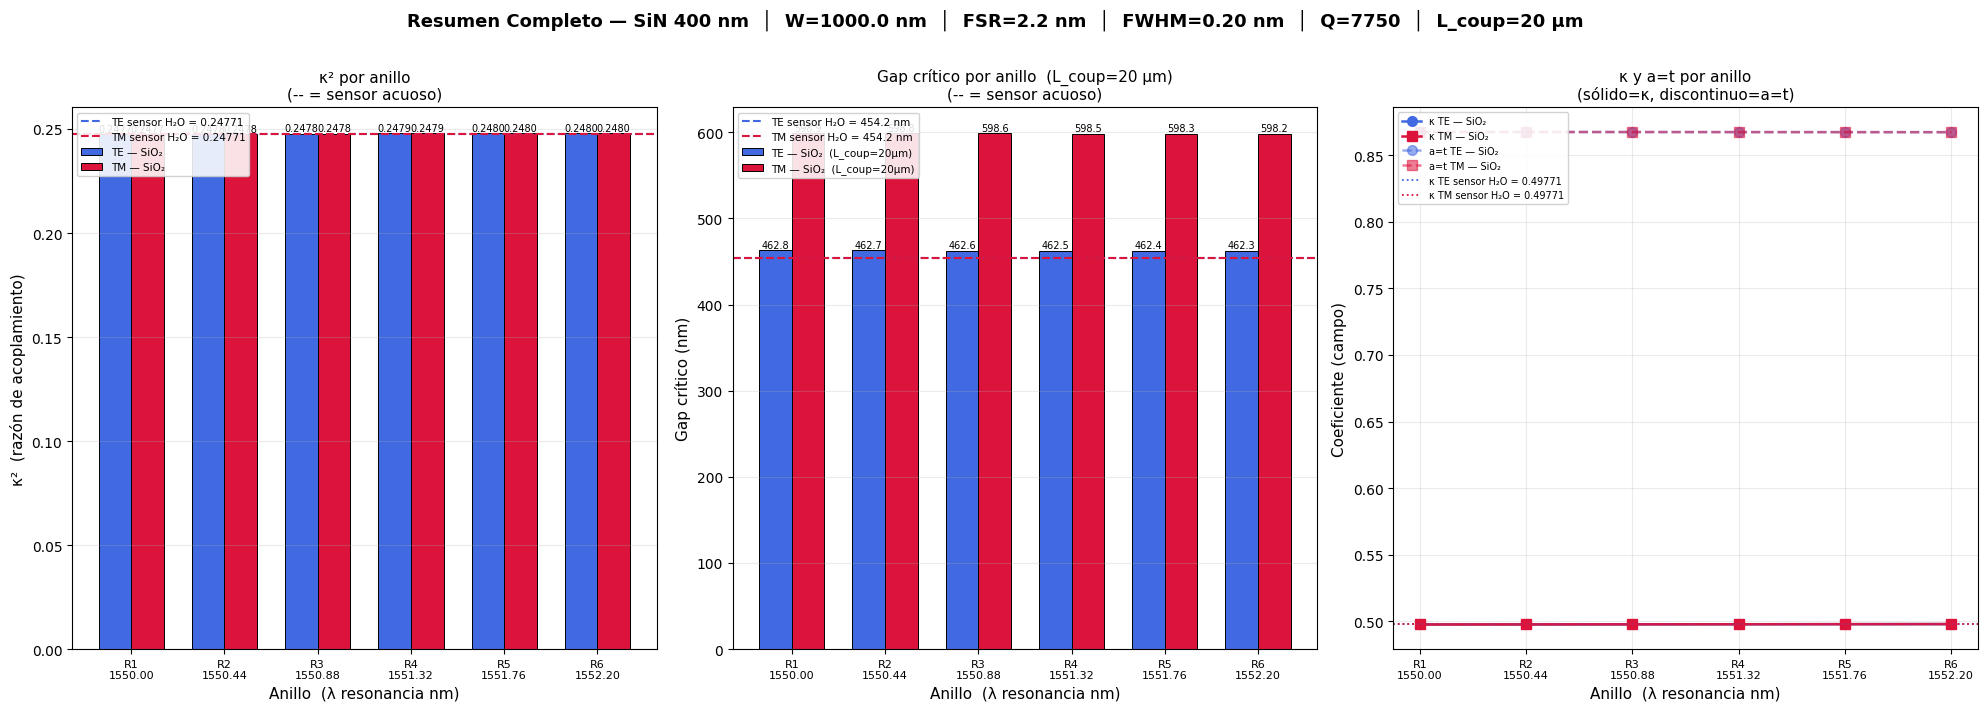

In [32]:
# ═══════════════════════════════════════════════════════════════════════════════
# RESUMEN DE DISEÑO COMPLETO — con coeficientes de acoplamiento por anillo
# Usa exclusivamente variables ya existentes en el notebook
# ═══════════════════════════════════════════════════════════════════════════════

L_coup_sel_idx = 2          # L_coup = 20 µm (índice 2 en el array [5, 10, 20])
L_coup_sel_nm  = res_TE_aq['L_coup values (µm)'][L_coup_sel_idx]   # 20.0 µm

# ── n_eff @ 1550 nm — ya extraídos en bloques anteriores ─────────────────────
# neff_sio2_TE_1550, neff_sio2_TM_1550  ← del bloque aqueous single-strip plot
# neff_aq_TE_1550,   neff_aq_TM_1550   ← del bloque aqueous single-strip plot

# ── Gaps para L_coup=20µm — ya interpolados en bloques anteriores ─────────────
# gap_critical[pol_idx][L_coup_sel_idx]  ← SiO2 clad, sweep_gap (600-800nm)
# gap_crit_aq [pol_idx][L_coup_sel_idx]  ← H2O  clad, sweep_gap_aq (400-700nm)
gap_sio2_TE_20 = gap_critical[0][L_coup_sel_idx] * 1e3   # nm
gap_sio2_TM_20 = gap_critical[1][L_coup_sel_idx] * 1e3   # nm
gap_aq_TE_20   = gap_crit_aq [0][L_coup_sel_idx] * 1e3   # nm
gap_aq_TM_20   = gap_crit_aq [1][L_coup_sel_idx] * 1e3   # nm

# ── Recalcular critical coupling para cada anillo de referencia (SiO2) ────────
# Cada anillo tiene su propia λ, R, L_ring → sus propios a, t, κ, κ²
# Q constante → FWHM_anillo = λ_anillo / Q = λ_anillo * FWHM_um / lambda_0_um

res_per_ring_TE = []
res_per_ring_TM = []

for wave_idx, wave_values in enumerate(sweep_wavelength):

    wl_um = wave_values

    # n_group a esa λ exacta — SiO2 clad, safe_width_idx, de sim_data_arr_modes
    ng_te = float(
        sim_data_arr_modes[0][safe_width_idx]
        .modes_raw.n_group
        .isel(mode_index=0).squeeze().values[wave_idx]
    )
    ng_tm = float(
        sim_data_arr_modes[1][safe_width_idx]
        .modes_raw.n_group
        .isel(mode_index=0).squeeze().values[wave_idx]
    )

    # Radio fase-coincidente — ya en results_TE/TM[wave_idx]
    R_te_um = float(results_TE[wave_idx]['R (µm)'])
    R_tm_um = float(results_TM[wave_idx]['R (µm)'])
    L_te    = 2 * np.pi * R_te_um
    L_tm    = 2 * np.pi * R_tm_um

    # FWHM escalado manteniendo Q constante
    FWHM_ring = wl_um * FWHM_um / lambda_0_um

    res_per_ring_TE.append(
        critical_coupling_analysis(
            ng_te, wl_um, FWHM_ring, L_te, FSR_target_nm,
            f'TE ring{wave_idx+1}'
        )
    )
    res_per_ring_TM.append(
        critical_coupling_analysis(
            ng_tm, wl_um, FWHM_ring, L_tm, FSR_target_nm,
            f'TM ring{wave_idx+1}'
        )
    )

# ── Gap por anillo de referencia para L_coup=20µm ────────────────────────────
# Curva Δn(gap) simulada: delta_n_gap[pol_idx] sobre sweep_gap (SiO2 clad)
# Invertir para interpolación (Δn decrece con gap creciente)

gap_per_ring_TE = []
gap_per_ring_TM = []
Dn_per_ring_TE  = []
Dn_per_ring_TM  = []

Dn_flip_TE  = delta_n_gap[0][::-1]
gap_flip_TE = sweep_gap[::-1]
Dn_flip_TM  = delta_n_gap[1][::-1]
gap_flip_TM = sweep_gap[::-1]

for wave_idx in range(len(sweep_wavelength)):

    Dn_tgt_te = res_per_ring_TE[wave_idx]['Δn values'][L_coup_sel_idx]
    Dn_tgt_tm = res_per_ring_TM[wave_idx]['Δn values'][L_coup_sel_idx]

    gap_te = np.interp(Dn_tgt_te, Dn_flip_TE, gap_flip_TE)
    gap_tm = np.interp(Dn_tgt_tm, Dn_flip_TM, gap_flip_TM)

    gap_per_ring_TE.append(gap_te * 1e3)
    gap_per_ring_TM.append(gap_tm * 1e3)
    Dn_per_ring_TE.append(np.interp(gap_te, sweep_gap, delta_n_gap[0]))
    Dn_per_ring_TM.append(np.interp(gap_tm, sweep_gap, delta_n_gap[1]))

# ── Imprimir tabla ─────────────────────────────────────────────────────────────
SEP  = "═" * 172
sep2 = "─" * 172

print(f"\n{SEP}")
print(f"  PLATAFORMA SiN — RESUMEN COMPLETO DE DISEÑO")
print(f"  Espesor={core_thickness*1e3:.0f} nm  │  Ancho={safe_width_nm:.1f} nm  │  "
      f"FSR={FSR_target_nm:.1f} nm  │  FWHM={FWHM_nm:.2f} nm  │  "
      f"Q={res_TE_aq['Q']:.0f}  │  L_coup={L_coup_sel_nm:.0f} µm")
print(SEP)

header = (f"  {'Anillo':<10} {'λ res.(nm)':<13} {'Cladding':<14} "
          f"{'R (µm)':<10} {'L=2πR(µm)':<12} "
          f"{'Gap(nm)':<11} {'n_g':<10} {'n_eff@1550':<13} "
          f"{'a=t':<10} {'κ':<10} {'κ²':<10} "
          f"{'RT loss(dB)':<13} {'α(dB/cm)':<11} {'Δn@gap'}")

for pol_label, pol_idx, res_rings, gap_rings, Dn_rings, \
    R_sensor, L_sensor, ng_sensor, neff_sensor, \
    gap_sensor, res_sensor in [
        ('TE', 0, res_per_ring_TE, gap_per_ring_TE, Dn_per_ring_TE,
         R_ring_TE_aq_um, L_ring_TE_aq, n_g_TE_aq, neff_aq_TE_1550,
         gap_aq_TE_20, res_TE_aq),
        ('TM', 1, res_per_ring_TM, gap_per_ring_TM, Dn_per_ring_TM,
         R_ring_TM_aq_um, L_ring_TM_aq, n_g_TM_aq, neff_aq_TM_1550,
         gap_aq_TM_20, res_TM_aq),
    ]:

    print(f"\n  ── POLARIZACIÓN {pol_label} {'─'*100}")
    print(header)
    print(f"  {sep2}")

    # Anillo 0: sensor acuoso
    print(f"  {'0 (sensor)':<10} {sweep_wavelength[0]*1e3:<13.4f} "
          f"{'H₂O (1.3166)':<14} "
          f"{R_sensor:<10.4f} {L_sensor:<12.4f} "
          f"{gap_sensor:<11.2f} {ng_sensor:<10.5f} {neff_sensor:<13.5f} "
          f"{res_sensor['a (field trans.)']:<10.5f} "
          f"{res_sensor['κ (cross-coup.)']:<10.5f} "
          f"{res_sensor['κ² (power coup.)']:<10.5f} "
          f"{res_sensor['RT loss (dB)']:<13.4f} "
          f"{res_sensor['α_power (dB/cm)']:<11.4f} "
          f"{Dn_interp_aq[pol_idx][L_coup_sel_idx]:.5f}")

    # Anillos 1-6: referencia SiO2
    for wave_idx in range(len(sweep_wavelength)):
        r    = res_rings[wave_idx]
        wl   = float(results_TE[wave_idx]['λ (nm)'])
        R_um = float(results_TE[wave_idx]['R (µm)']) if pol_label=='TE' \
               else float(results_TM[wave_idx]['R (µm)'])
        print(f"  {str(wave_idx+1):<10} {wl:<13.4f} "
              f"{'SiO₂ (1.4469)':<14} "
              f"{R_um:<10.4f} {r['L_ring (µm)']:<12.4f} "
              f"{gap_rings[wave_idx]:<11.2f} {r['n_g']:<10.5f} "
              f"{(neff_sio2_TE_1550 if pol_label=='TE' else neff_sio2_TM_1550):<13.5f} "
              f"{r['a (field trans.)']:<10.5f} "
              f"{r['κ (cross-coup.)']:<10.5f} "
              f"{r['κ² (power coup.)']:<10.5f} "
              f"{r['RT loss (dB)']:<13.4f} "
              f"{r['α_power (dB/cm)']:<11.4f} "
              f"{Dn_rings[wave_idx]:.5f}")

    print(f"  {sep2}")

# ── Notas ──────────────────────────────────────────────────────────────────────
print(f"""
  LEYENDA:
  λ res.      Longitud de onda de resonancia
  R           Radio fase-coincidente  (2πR = m·λ)
  L=2πR       Longitud de recorrido completo
  Gap         Separación bus-anillo para acoplamiento crítico @ L_coup={L_coup_sel_nm:.0f} µm
  n_g         Índice de grupo @ λ resonancia
  n_eff       Índice efectivo modo fundamental @ 1550 nm
  a = t       Coeficiente de auto-acoplamiento (crítico: t = a)
  κ           Coeficiente de acoplamiento cruzado (campo)
  κ²          Razón de acoplamiento de potencia
  RT loss     Pérdida por vuelta completa (dB)
  α           Pérdida de propagación (dB/cm)
  Δn@gap      Δn simulado (n_even−n_odd) en el gap interpolado
""")
print(SEP)

# ── Figura ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

wl_plot   = np.array([float(r['λ (nm)']) for r in results_TE])
x_pos     = np.arange(len(sweep_wavelength))
ring_lbls = [f"R{i+1}\n{wl:.2f}" for i, wl in enumerate(wl_plot)]
bar_w     = 0.35

kappa2_TE = [r['κ² (power coup.)'] for r in res_per_ring_TE]
kappa2_TM = [r['κ² (power coup.)'] for r in res_per_ring_TM]
kappa_TE  = [r['κ (cross-coup.)']  for r in res_per_ring_TE]
kappa_TM  = [r['κ (cross-coup.)']  for r in res_per_ring_TM]
a_TE      = [r['a (field trans.)'] for r in res_per_ring_TE]
a_TM      = [r['a (field trans.)'] for r in res_per_ring_TM]

# Panel 1: κ² por anillo
ax0 = axes[0]
b1 = ax0.bar(x_pos - bar_w/2, kappa2_TE, bar_w,
             color='royalblue', edgecolor='black', linewidth=0.7,
             label='TE — SiO₂')
b2 = ax0.bar(x_pos + bar_w/2, kappa2_TM, bar_w,
             color='crimson', edgecolor='black', linewidth=0.7,
             label='TM — SiO₂')
ax0.axhline(res_TE_aq['κ² (power coup.)'], color='royalblue',
            linestyle='--', linewidth=1.5,
            label=f"TE sensor H₂O = {res_TE_aq['κ² (power coup.)']:.5f}")
ax0.axhline(res_TM_aq['κ² (power coup.)'], color='crimson',
            linestyle='--', linewidth=1.5,
            label=f"TM sensor H₂O = {res_TM_aq['κ² (power coup.)']:.5f}")
for bar, val in zip(list(b1)+list(b2), kappa2_TE+kappa2_TM):
    ax0.text(bar.get_x()+bar.get_width()/2, val+1e-5,
             f"{val:.4f}", ha='center', va='bottom', fontsize=7)
ax0.set_xticks(x_pos)
ax0.set_xticklabels(ring_lbls, fontsize=8)
ax0.set_xlabel("Anillo  (λ resonancia nm)",   fontsize=11)
ax0.set_ylabel("κ²  (razón de acoplamiento)", fontsize=11)
ax0.set_title("κ² por anillo\n(-- = sensor acuoso)", fontsize=11)
ax0.legend(fontsize=7.5, loc='upper left', framealpha=0.88)
ax0.grid(True, alpha=0.25, axis='y')

# Panel 2: Gap por anillo
ax1 = axes[1]
b3 = ax1.bar(x_pos - bar_w/2, gap_per_ring_TE, bar_w,
             color='royalblue', edgecolor='black', linewidth=0.7,
             label=f'TE — SiO₂  (L_coup={L_coup_sel_nm:.0f}µm)')
b4 = ax1.bar(x_pos + bar_w/2, gap_per_ring_TM, bar_w,
             color='crimson', edgecolor='black', linewidth=0.7,
             label=f'TM — SiO₂  (L_coup={L_coup_sel_nm:.0f}µm)')
ax1.axhline(gap_aq_TE_20, color='royalblue', linestyle='--', linewidth=1.5,
            label=f'TE sensor H₂O = {gap_aq_TE_20:.1f} nm')
ax1.axhline(gap_aq_TM_20, color='crimson',   linestyle='--', linewidth=1.5,
            label=f'TM sensor H₂O = {gap_aq_TM_20:.1f} nm')
for bar, val in zip(list(b3)+list(b4), gap_per_ring_TE+gap_per_ring_TM):
    ax1.text(bar.get_x()+bar.get_width()/2, val+0.5,
             f"{val:.1f}", ha='center', va='bottom', fontsize=7)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(ring_lbls, fontsize=8)
ax1.set_xlabel("Anillo  (λ resonancia nm)", fontsize=11)
ax1.set_ylabel("Gap crítico (nm)",           fontsize=11)
ax1.set_title(f"Gap crítico por anillo  (L_coup={L_coup_sel_nm:.0f} µm)\n"
              f"(-- = sensor acuoso)", fontsize=11)
ax1.legend(fontsize=7.5, loc='upper left', framealpha=0.88)
ax1.grid(True, alpha=0.25, axis='y')

# Panel 3: κ y a=t por anillo
ax2 = axes[2]
ax2.plot(x_pos, kappa_TE, color='royalblue', marker='o',
         linewidth=1.8, markersize=7, label='κ TE — SiO₂')
ax2.plot(x_pos, kappa_TM, color='crimson',   marker='s',
         linewidth=1.8, markersize=7, label='κ TM — SiO₂')
ax2.plot(x_pos, a_TE, color='royalblue', marker='o',
         linewidth=1.8, markersize=7, linestyle='--', alpha=0.55,
         label='a=t TE — SiO₂')
ax2.plot(x_pos, a_TM, color='crimson',   marker='s',
         linewidth=1.8, markersize=7, linestyle='--', alpha=0.55,
         label='a=t TM — SiO₂')
ax2.axhline(res_TE_aq['κ (cross-coup.)'], color='royalblue',
            linestyle=':', linewidth=1.3,
            label=f"κ TE sensor H₂O = {res_TE_aq['κ (cross-coup.)']:.5f}")
ax2.axhline(res_TM_aq['κ (cross-coup.)'], color='crimson',
            linestyle=':', linewidth=1.3,
            label=f"κ TM sensor H₂O = {res_TM_aq['κ (cross-coup.)']:.5f}")
ax2.set_xticks(x_pos)
ax2.set_xticklabels(ring_lbls, fontsize=8)
ax2.set_xlabel("Anillo  (λ resonancia nm)",  fontsize=11)
ax2.set_ylabel("Coeficiente (campo)",         fontsize=11)
ax2.set_title("κ y a=t por anillo\n(sólido=κ, discontinuo=a=t)", fontsize=11)
ax2.legend(fontsize=7, loc='upper left', framealpha=0.88)
ax2.grid(True, alpha=0.25)

plt.suptitle(
    f"Resumen Completo — SiN {core_thickness*1e3:.0f} nm  │  "
    f"W={safe_width_nm:.1f} nm  │  FSR={FSR_target_nm:.1f} nm  │  "
    f"FWHM={FWHM_nm:.2f} nm  │  Q={res_TE_aq['Q']:.0f}  │  "
    f"L_coup={L_coup_sel_nm:.0f} µm",
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    str(data_dir / f"{version_name}_full_design_summary.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()

Barrido de índice de cladding:
  Desde n = 1.3166  (agua pura @ 1550 nm)
  Hasta n = 1.3500  (solución concentrada)
  Paso   Δn = 0.00176 RIU
  Puntos   = 20


21:55:29 Hora est. Pacífico, Sudamérica WARNING: updating ModeSimulation from   
                                        2.10.1 to 2.10.2                        

                                        WARNING: Structure at 'structures[0]'   
                                        has bounds that extend exactly to       
                                        simulation edges. This can cause        
                                        unexpected behavior. If intending to    
                                        extend the structure to infinity along  
                                        one dimension, use td.inf as a size     
                                        variable instead to make this explicit. 

21:55:30 Hora est. Pacífico, Sudamérica WARNING: Structure at 'structures[0]'   
                                        has bounds that extend exactly to       
                                        simulation edges. This can cause        
                                        unexpected behavior. If intending to    
                                        extend the structure to infinity along  
                                        one dimension, use td.inf as a size     
                                        variable instead to make this explicit. 

                                        WARNING: The original simulation is     
                                        symmetric along z direction. The mode   
                                        simulation region does cross the        
                                        symmetry plane but is not symmetric with
                                        respect to it. To preserve correct      
                                        symmetry, the requested simulation      
                                        region will be expanded by the solver.  

...

                                        WARNING: The original simulation is     
                                        symmetric along z direction. The mode   
                                        simulation region does cross the        
                                        symmetry plane but is not symmetric with
                                        respect to it. To preserve correct      
                                        symmetry, the requested simulation      
                                        region will be expanded by the solver.  

21:55:48 Hora est. Pacífico, Sudamérica WARNING: Structure at 'structures[0]'   
                                        has bounds that extend exactly to       
                                        simulation edges. This can cause        
                                        unexpected behavior. If intending to    
                                        extend the structure to infinity along  
                                        one dimension, use td.inf as a size     
                                        variable instead to make this explicit. 

                                        WARNING: Structure at 'structures[0]'   
                                        has bounds that extend exactly to       
                                        simulation edges. This can cause        
                                        unexpected behavior. If intending to    
                                        extend the structure to infinity along  
                                        one dimension, use td.inf as a size     
                                        variable instead to make this explicit. 

                                        WARNING: The original simulation is     
                                        symmetric along z direction. The mode   
                                        simulation region does cross the        
                                        symmetry plane but is not symmetric with
                                        respect to it. To preserve correct      
                                        symmetry, the requested simulation      
                                        region will be expanded by the solver.  

  Cargado  [TM] n_clad=1.3500

Costo máximo estimado: 0

══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  BARRIDO DE ÍNDICE DE CLADDING — n_eff vs n_clad
  Ancho=1000.0 nm  │  Espesor=400 nm  │  λ₀=1550.0 nm  │  Sustrato=SiO₂  │  Cladding=analito acuoso
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  n_clad       n_eff TE       S_TE (RIU/RIU)     n_g TE         n_eff TM       S_TM (RIU/RIU)     n_g TM
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  1.3166       1.607959       0.164577           2.031514       1.607959       0.164577           2.031514 ◄ agua pura
  1.3184       1.608249       0.207021           2.031119       1.608249       0.207021           2.031119
  1.3201       1.608687       0.212627           2.031261       1.608687       0.212627           2.031261
  1.3219       1.608

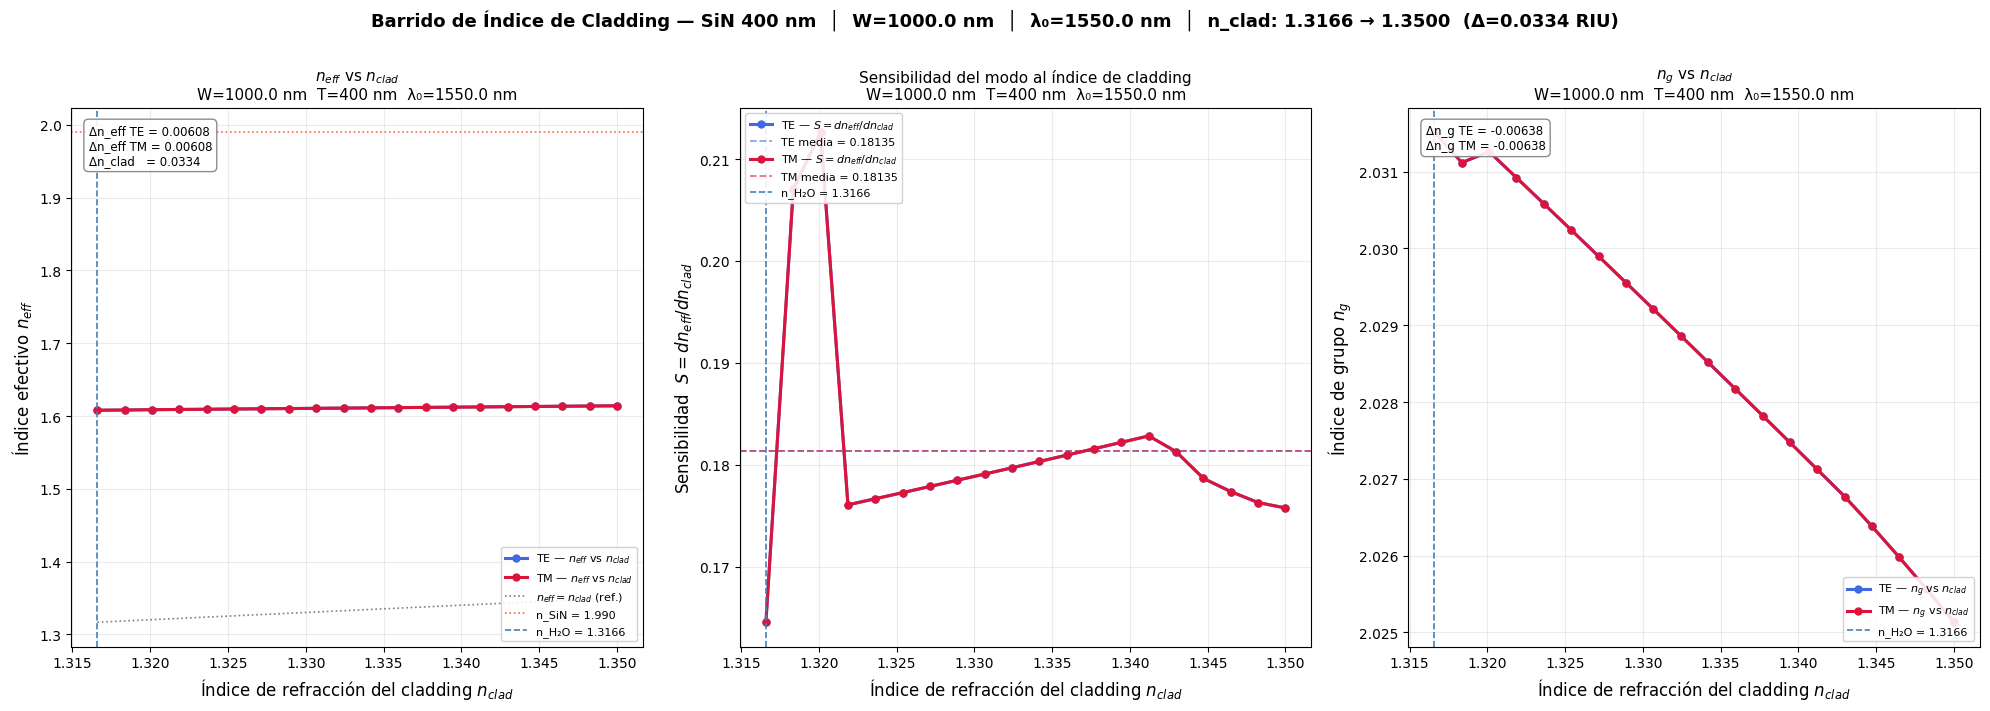

In [33]:
# ═══════════════════════════════════════════════════════════════════════════════
# BARRIDO DE ÍNDICE DE CLADDING — Simulación de sensado en analito acuoso
# Simula el incremento de n_clad desde agua pura hasta solución concentrada
# Reutiliza: fixed_width, core_thickness, sweep_wavelength, sweep_freq,
#            n_water_1550, core_medium, data_dir, version_name
# ═══════════════════════════════════════════════════════════════════════════════

# ── Parámetros del barrido ────────────────────────────────────────────────────
# Rango típico para soluciones acuosas con analito disuelto:
# n_water = 1.3166 (base) hasta ~1.3500 (solución concentrada ~30% sacarosa)
# 20 puntos dan resolución de ~1.7e-3 RIU por paso

n_clad_points   = 20
sweep_n_clad    = np.linspace(1.3166, 1.3500, n_clad_points)
version_name_nclad = "SiN_sim_400_nclad_sweep_V1"

print(f"Barrido de índice de cladding:")
print(f"  Desde n = {sweep_n_clad[0]:.4f}  (agua pura @ 1550 nm)")
print(f"  Hasta n = {sweep_n_clad[-1]:.4f}  (solución concentrada)")
print(f"  Paso   Δn = {sweep_n_clad[1]-sweep_n_clad[0]:.5f} RIU")
print(f"  Puntos   = {n_clad_points}")

# ── Función de simulación ─────────────────────────────────────────────────────
def build_nclad_sweep_simulation(
    core_width      = fixed_width,
    core_thickness  = 0.400,
    sweep_n_clad    = np.linspace(1.3166, 1.3500, 20),
    wavelength      = sweep_wavelength,
    version_name    = "SiN_nclad_sweep"
):
    base_path = f"data_STRp_SiN_mode_analysis/{version_name}"
    os.makedirs(base_path, exist_ok=True)

    freqs = td.C_0 / wavelength

    core_medium = td.Medium(
        name         = 'core_SiN_medium',
        permittivity = 1.99**2,
    )
    substrate_medium = td.Medium(
        name         = 'substrate_SiO2_medium',
        permittivity = 1.4469404291704726**2,
    )

    # sim_data_arr[pol_idx][nclad_idx] → ModeSimulationData
    sim_data_arr = [[], []]
    sim_arr      = [[], []]
    estimate     = 0

    for (pol_idx, pol_value) in enumerate(['TE', 'TM']):

        pol_folder = f"{base_path}/pol{pol_value}"
        os.makedirs(pol_folder, exist_ok=True)

        for (nclad_idx, n_clad_val) in enumerate(sweep_n_clad):

            # nombre de archivo con n_clad codificado como entero de 6 dígitos
            filename = f"{pol_folder}/nclad_{int(round(n_clad_val * 1e4))}.hdf5"

            analyte_medium = td.Medium(
                name         = f'analyte_n{n_clad_val:.4f}',
                permittivity = n_clad_val**2,
            )

            waveguide = td.Structure(
                geometry = td.Box(
                    center = [0, 0, core_thickness / 2],
                    size   = [td.inf, core_width, core_thickness]
                ),
                name   = 'waveguide',
                medium = core_medium
            )

            substrate = td.Structure(
                geometry = td.Box(
                    center = [0, 0, -3.5 / 2],
                    size   = [td.inf, td.inf, 3.5]
                ),
                name   = 'substrate',
                medium = substrate_medium
            )

            sim_arr[pol_idx].append(td.ModeSimulation(
                freqs     = freqs,
                mode_spec = td.ModeSpec(
                    target_neff      = 1.99,
                    num_modes        = 4,
                    sort_spec        = {
                        'filter_reference' : 0,
                        'filter_order'     : 'over',
                        'sort_order'       : 'ascending',
                        'track_freq'       : 'central'
                    },
                    group_index_step = True,
                ),
                size      = [7, 7, 7],
                grid_spec = td.GridSpec(
                    grid_x     = td.AutoGrid(min_steps_per_wvl=15),
                    grid_y     = td.AutoGrid(min_steps_per_wvl=15),
                    grid_z     = td.AutoGrid(min_steps_per_wvl=15),
                    wavelength = 1.550,
                ),
                version    = '2.10.1',
                medium     = analyte_medium,   # cladding = analito a n variable
                sources    = [],
                monitors   = [],
                structures = [substrate, waveguide],
                symmetry   = [0, 0,  1] if pol_value == 'TE' else [0, 0, -1],
                plane      = td.Box(
                    center = [0, 0, core_thickness / 2],
                    size   = [0, 7, 7]
                )
            ))

            if os.path.exists(filename):
                sim_data_arr[pol_idx].append(
                    td.ModeSimulationData.from_file(Path(filename))
                )
                print(f"  Cargado  [{pol_value}] n_clad={n_clad_val:.4f}")
            else:
                task_name = (f"{version_name}_P{pol_value}"
                             f"_N{int(round(n_clad_val*1e4))}")
                job = web.Job(
                    simulation = sim_arr[pol_idx][nclad_idx],
                    task_name  = task_name
                )
                print(f"  Corriendo [{pol_value}] n_clad={n_clad_val:.4f}")
                sim_data_arr[pol_idx].append(job.run())
                sim_data_arr[pol_idx][nclad_idx].to_file(filename)

                Job = web.Job(
                    simulation = sim_arr[pol_idx][nclad_idx],
                    task_name  = "cost_estimate"
                )
                estimate += Job.estimate_cost()

    print(f"\nCosto máximo estimado: {estimate}")
    return sim_data_arr, sim_arr


# ── Correr simulación ─────────────────────────────────────────────────────────
sim_data_nclad, sim_arr_nclad = build_nclad_sweep_simulation(
    core_width     = fixed_width,
    core_thickness = core_thickness,
    sweep_n_clad   = sweep_n_clad,
    wavelength     = sweep_wavelength,
    version_name   = version_name_nclad
)

# ═══════════════════════════════════════════════════════════════════════════════
# EXTRACCIÓN, TABLA Y GRÁFICAS
# ═══════════════════════════════════════════════════════════════════════════════

# ── Extraer n_eff @ lambda_0_idx para cada n_clad y polarización ──────────────
# neff_vs_nclad[pol_idx][nclad_idx] → escalar n_eff del modo fundamental

neff_vs_nclad = [[], []]
ng_vs_nclad   = [[], []]

for pol_idx in range(2):
    for nclad_idx in range(n_clad_points):

        neff_val = float(
            sim_data_nclad[pol_idx][nclad_idx]
            .modes_raw.n_complex.abs
            .isel(mode_index=0, f=lambda_0_idx)
            .squeeze().values
        )
        ng_val = float(
            sim_data_nclad[pol_idx][nclad_idx]
            .modes_raw.n_group
            .isel(mode_index=0, f=lambda_0_idx)
            .squeeze().values
        )
        neff_vs_nclad[pol_idx].append(neff_val)
        ng_vs_nclad  [pol_idx].append(ng_val)

    neff_vs_nclad[pol_idx] = np.array(neff_vs_nclad[pol_idx])
    ng_vs_nclad  [pol_idx] = np.array(ng_vs_nclad  [pol_idx])

# ── Sensibilidad: dn_eff / dn_clad (RIU/RIU) via diferencias finitas ─────────
sensitivity_TE = np.gradient(neff_vs_nclad[0], sweep_n_clad)
sensitivity_TM = np.gradient(neff_vs_nclad[1], sweep_n_clad)

# ── Imprimir tabla ────────────────────────────────────────────────────────────
SEP  = "═" * 110
sep2 = "─" * 110

print(f"\n{SEP}")
print(f"  BARRIDO DE ÍNDICE DE CLADDING — n_eff vs n_clad")
print(f"  Ancho={safe_width_nm:.1f} nm  │  Espesor={core_thickness*1e3:.0f} nm  │  "
      f"λ₀={lambda_0_um*1e3:.1f} nm  │  Sustrato=SiO₂  │  Cladding=analito acuoso")
print(SEP)
print(f"  {'n_clad':<12} "
      f"{'n_eff TE':<14} {'S_TE (RIU/RIU)':<18} {'n_g TE':<14} "
      f"{'n_eff TM':<14} {'S_TM (RIU/RIU)':<18} {'n_g TM'}")
print(f"  {sep2}")

for i in range(n_clad_points):
    marker = " ◄ agua pura" if i == 0 else ""
    print(f"  {sweep_n_clad[i]:<12.4f} "
          f"{neff_vs_nclad[0][i]:<14.6f} {sensitivity_TE[i]:<18.6f} "
          f"{ng_vs_nclad[0][i]:<14.6f} "
          f"{neff_vs_nclad[1][i]:<14.6f} {sensitivity_TM[i]:<18.6f} "
          f"{ng_vs_nclad[1][i]:.6f}{marker}")

print(f"  {sep2}")
print(f"  Sensibilidad promedio TE : "
      f"{np.mean(sensitivity_TE):.6f} RIU/RIU  │  "
      f"máx={np.max(sensitivity_TE):.6f}  mín={np.min(sensitivity_TE):.6f}")
print(f"  Sensibilidad promedio TM : "
      f"{np.mean(sensitivity_TM):.6f} RIU/RIU  │  "
      f"máx={np.max(sensitivity_TM):.6f}  mín={np.min(sensitivity_TM):.6f}")
print(f"\n  Δn_eff total TE : "
      f"{neff_vs_nclad[0][-1]-neff_vs_nclad[0][0]:.6f} RIU  "
      f"para Δn_clad = {sweep_n_clad[-1]-sweep_n_clad[0]:.4f} RIU")
print(f"  Δn_eff total TM : "
      f"{neff_vs_nclad[1][-1]-neff_vs_nclad[1][0]:.6f} RIU  "
      f"para Δn_clad = {sweep_n_clad[-1]-sweep_n_clad[0]:.4f} RIU")
print(SEP)

# ── Gráficas ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors_pol = ['royalblue', 'crimson']

# ── Panel 1: n_eff vs n_clad ──────────────────────────────────────────────────
ax0 = axes[0]

for pol_idx, (pol_value, color) in enumerate(zip(['TE', 'TM'], colors_pol)):
    ax0.plot(
        sweep_n_clad, neff_vs_nclad[pol_idx],
        color=color, linewidth=2.2,
        marker='o', markersize=5,
        label=f"{pol_value} — $n_{{eff}}$ vs $n_{{clad}}$"
    )

# línea diagonal de referencia n_eff = n_clad (límite inferior teórico)
ax0.plot(
    sweep_n_clad, sweep_n_clad,
    color='gray', linewidth=1.2, linestyle=':',
    label='$n_{eff} = n_{clad}$ (ref.)'
)
ax0.axhline(
    1.99, color='tomato', linewidth=1.2, linestyle=':',
    label='n_SiN = 1.990'
)
ax0.axvline(
    n_water_1550, color='steelblue', linewidth=1.2, linestyle='--',
    label=f'n_H₂O = {n_water_1550}'
)

# caja de resumen
stats_text = (
    f"Δn_eff TE = {neff_vs_nclad[0][-1]-neff_vs_nclad[0][0]:.5f}\n"
    f"Δn_eff TM = {neff_vs_nclad[1][-1]-neff_vs_nclad[1][0]:.5f}\n"
    f"Δn_clad   = {sweep_n_clad[-1]-sweep_n_clad[0]:.4f}"
)
ax0.text(
    0.03, 0.97, stats_text,
    transform=ax0.transAxes, fontsize=8.5,
    va='top', ha='left',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
              edgecolor='gray', alpha=0.9)
)
ax0.set_xlabel("Índice de refracción del cladding $n_{clad}$", fontsize=12)
ax0.set_ylabel("Índice efectivo $n_{eff}$",                    fontsize=12)
ax0.set_title(
    "$n_{eff}$ vs $n_{clad}$\n"
    f"W={safe_width_nm:.1f} nm  T={core_thickness*1e3:.0f} nm  "
    f"λ₀={lambda_0_um*1e3:.1f} nm",
    fontsize=11
)
ax0.legend(fontsize=8, loc='lower right', framealpha=0.88)
ax0.grid(True, alpha=0.25)

# ── Panel 2: Sensibilidad dn_eff/dn_clad vs n_clad ───────────────────────────
ax1 = axes[1]

for pol_idx, (pol_value, color, sens) in enumerate(zip(
    ['TE', 'TM'], colors_pol, [sensitivity_TE, sensitivity_TM]
)):
    ax1.plot(
        sweep_n_clad, sens,
        color=color, linewidth=2.2,
        marker='o', markersize=5,
        label=f"{pol_value} — $S = dn_{{eff}}/dn_{{clad}}$"
    )
    # promedio
    ax1.axhline(
        np.mean(sens), color=color, linestyle='--',
        linewidth=1.3, alpha=0.6,
        label=f"{pol_value} media = {np.mean(sens):.5f}"
    )

ax1.axvline(
    n_water_1550, color='steelblue', linewidth=1.2, linestyle='--',
    label=f'n_H₂O = {n_water_1550}'
)
ax1.set_xlabel("Índice de refracción del cladding $n_{clad}$", fontsize=12)
ax1.set_ylabel("Sensibilidad  $S = dn_{eff}/dn_{clad}$",       fontsize=12)
ax1.set_title(
    "Sensibilidad del modo al índice de cladding\n"
    f"W={safe_width_nm:.1f} nm  T={core_thickness*1e3:.0f} nm  "
    f"λ₀={lambda_0_um*1e3:.1f} nm",
    fontsize=11
)
ax1.legend(fontsize=8, loc='upper left', framealpha=0.88)
ax1.grid(True, alpha=0.25)

# ── Panel 3: n_group vs n_clad ────────────────────────────────────────────────
ax2 = axes[2]

for pol_idx, (pol_value, color) in enumerate(zip(['TE', 'TM'], colors_pol)):
    ax2.plot(
        sweep_n_clad, ng_vs_nclad[pol_idx],
        color=color, linewidth=2.2,
        marker='o', markersize=5,
        label=f"{pol_value} — $n_g$ vs $n_{{clad}}$"
    )

ax2.axvline(
    n_water_1550, color='steelblue', linewidth=1.2, linestyle='--',
    label=f'n_H₂O = {n_water_1550}'
)

stats_ng = (
    f"Δn_g TE = {ng_vs_nclad[0][-1]-ng_vs_nclad[0][0]:.5f}\n"
    f"Δn_g TM = {ng_vs_nclad[1][-1]-ng_vs_nclad[1][0]:.5f}"
)
ax2.text(
    0.03, 0.97, stats_ng,
    transform=ax2.transAxes, fontsize=8.5,
    va='top', ha='left',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
              edgecolor='gray', alpha=0.9)
)
ax2.set_xlabel("Índice de refracción del cladding $n_{clad}$", fontsize=12)
ax2.set_ylabel("Índice de grupo $n_g$",                        fontsize=12)
ax2.set_title(
    "$n_g$ vs $n_{clad}$\n"
    f"W={safe_width_nm:.1f} nm  T={core_thickness*1e3:.0f} nm  "
    f"λ₀={lambda_0_um*1e3:.1f} nm",
    fontsize=11
)
ax2.legend(fontsize=8, loc='lower right', framealpha=0.88)
ax2.grid(True, alpha=0.25)

plt.suptitle(
    f"Barrido de Índice de Cladding — SiN {core_thickness*1e3:.0f} nm  │  "
    f"W={safe_width_nm:.1f} nm  │  λ₀={lambda_0_um*1e3:.1f} nm  │  "
    f"n_clad: {sweep_n_clad[0]:.4f} → {sweep_n_clad[-1]:.4f}  "
    f"(Δ={sweep_n_clad[-1]-sweep_n_clad[0]:.4f} RIU)",
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    str(data_dir / f"{version_name_nclad}_neff_vs_nclad.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()